In [1]:
from google.colab import files
import os

# Verifica si el archivo ya existe para evitar recargar innecesariamente
file_name = 'Dataset_ML_Clasificacion_SLA_4.csv'
if not os.path.exists(file_name):
  uploaded = files.upload()
  for fn in uploaded.keys():
    print(f'Archivo "{fn}" cargado exitosamente.')
else:
  print(f'El archivo "{file_name}" ya existe en el entorno de Colab.')

El archivo "Dataset_ML_Clasificacion_SLA_4.csv" ya existe en el entorno de Colab.


1. Cargando el Dataset Consolidado (Pre-depuración de Data Leakage)...
Dimensiones del Dataset: (3442, 30)

1. ANÁLISIS EXPLORATORIO DE DATOS (EDA) Y ESTADÍSTICA DESCRIPTIVA

--- Resumen Estadístico de Variables Continuas Clave ---
       Volumen_GB  Velocidad_MB_s  Duracion_Sesion_Segundos
count     3442.00         3442.00                   3442.00
mean        10.75           13.00                    263.56
std        104.73           19.81                   1002.66
min          0.00            0.00                      0.00
25%          0.22            2.39                     55.00
50%          0.44            5.62                     79.00
75%          1.86           11.51                    280.00
max       2012.03          184.82                  18294.00


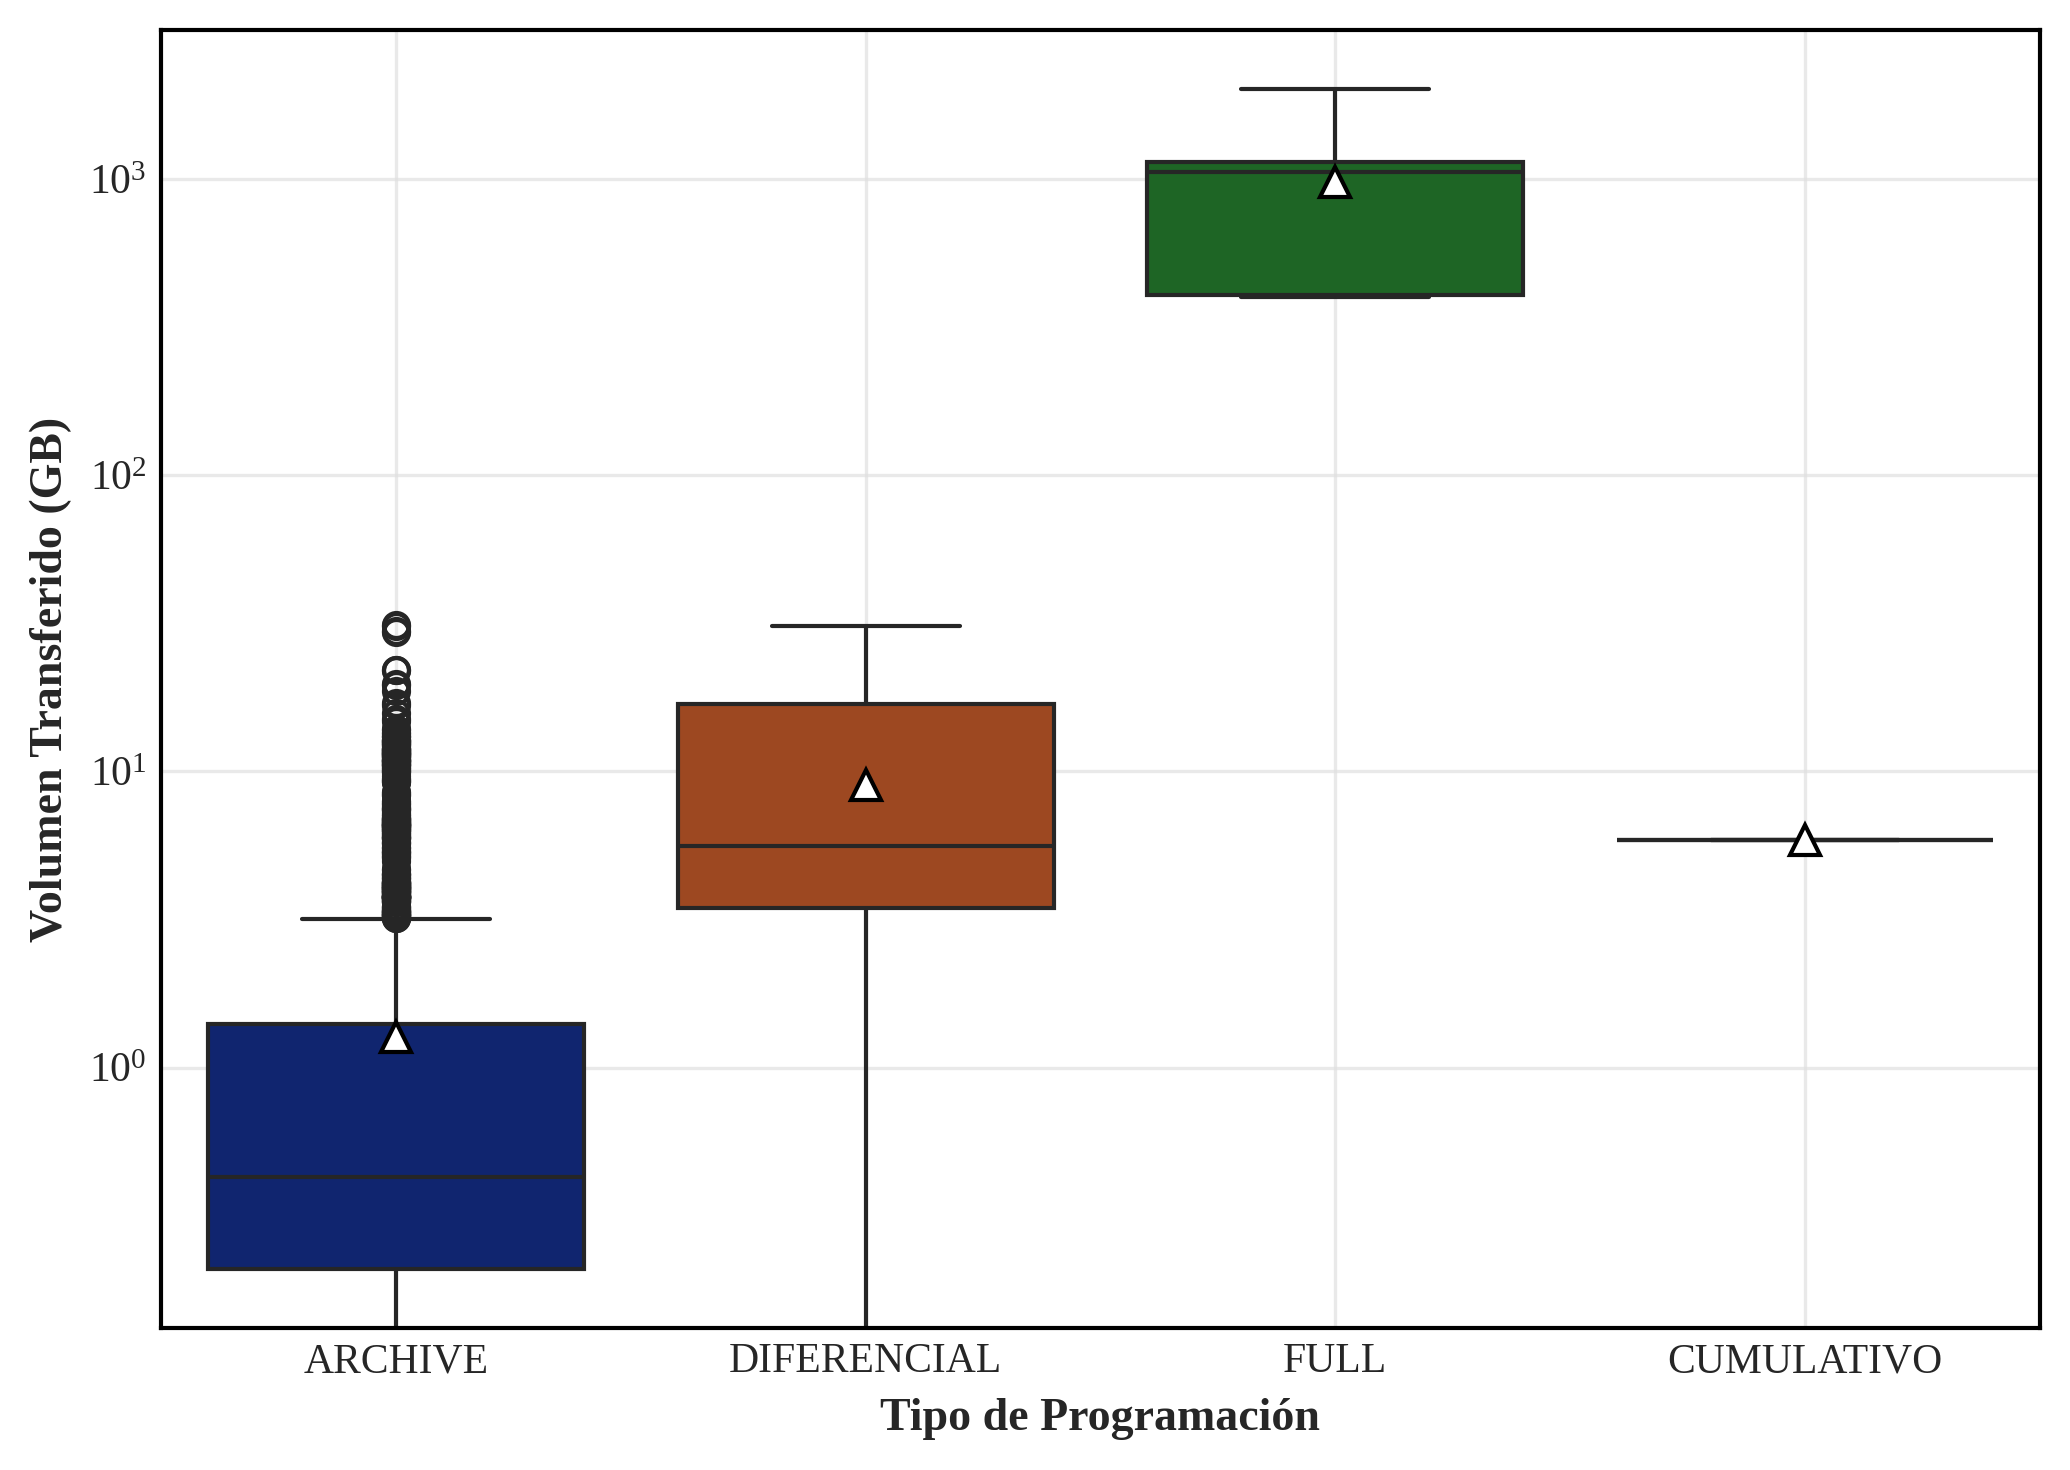

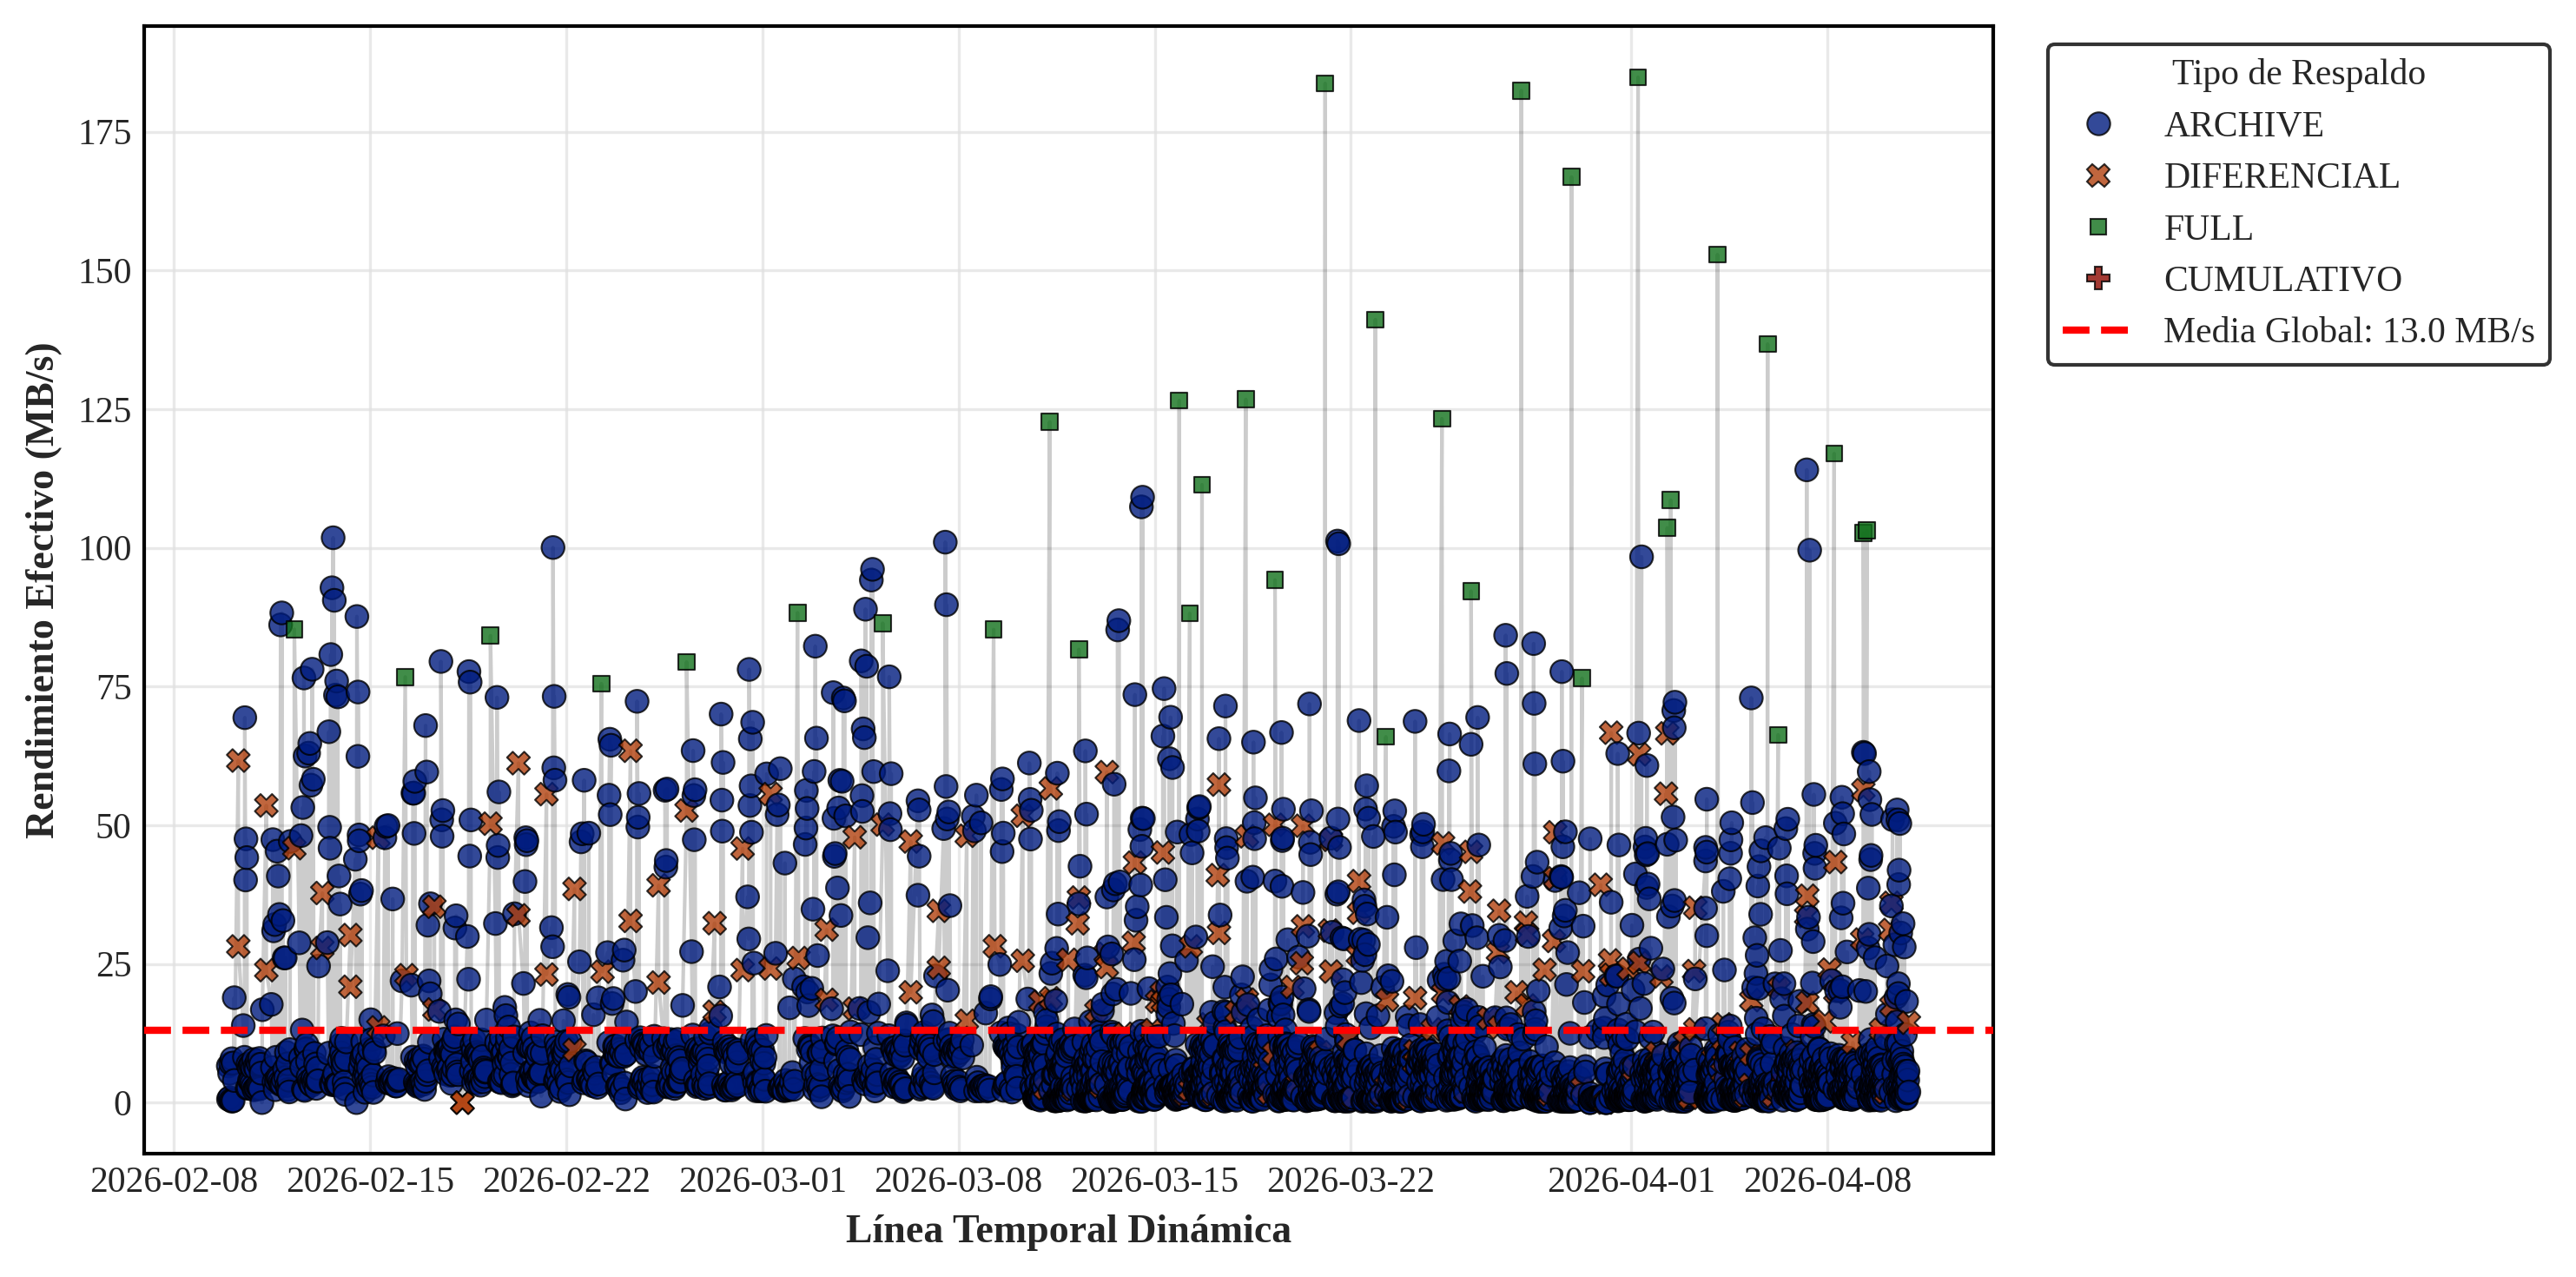

2. COMPORTAMIENTO FÍSICO: NO LINEALIDAD Y ESTIMADOR BASE

A. Análisis de Correlaciones (Volumen vs RTO Real):
   -> Pearson (Lineal estricta): 0.909
   -> Spearman (Monótona/Curva): 0.848


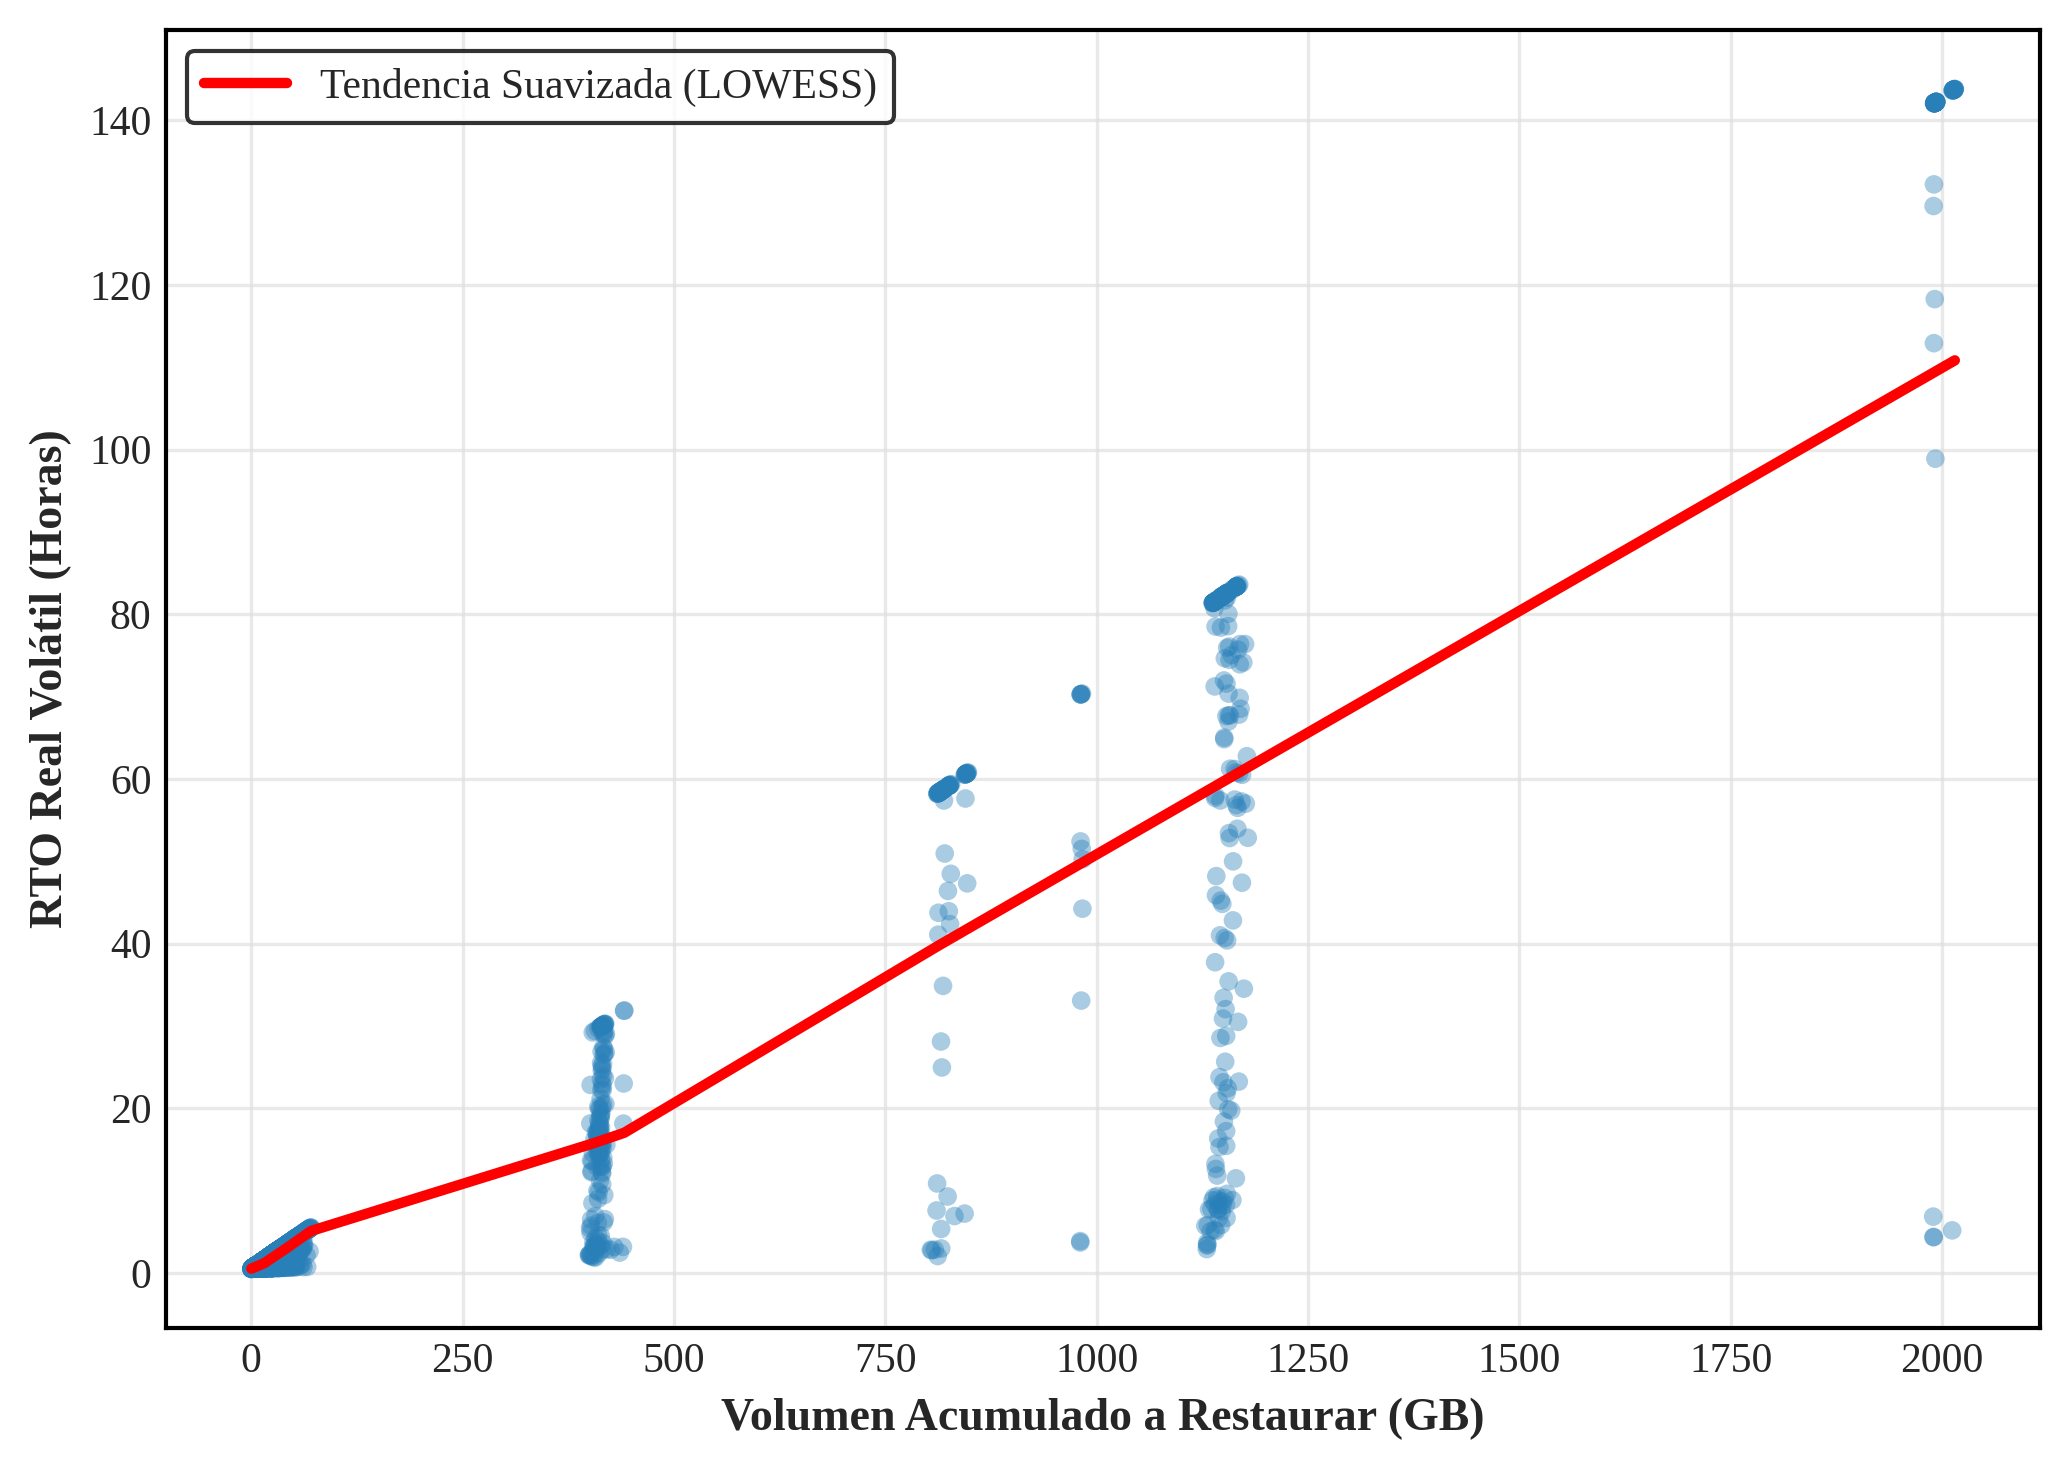

3. DIAGNÓSTICO MATEMÁTICO: RESET TEST Y HETEROCEDASTICIDAD

B. Test de Ramsey RESET (Especificación Lineal): F=1838.47, p-value=3.656086e-322
   [!] Se rechaza H0: El modelo lineal omite variables no lineales. La relación es definitivamente curva.

C. Test de Breusch-Pagan (Varianza del Error): LM=1549.46, p-value=0.000000e+00
   [!] Se rechaza H0: Existe HETEROCEDASTICIDAD significativa en el modelo lineal.


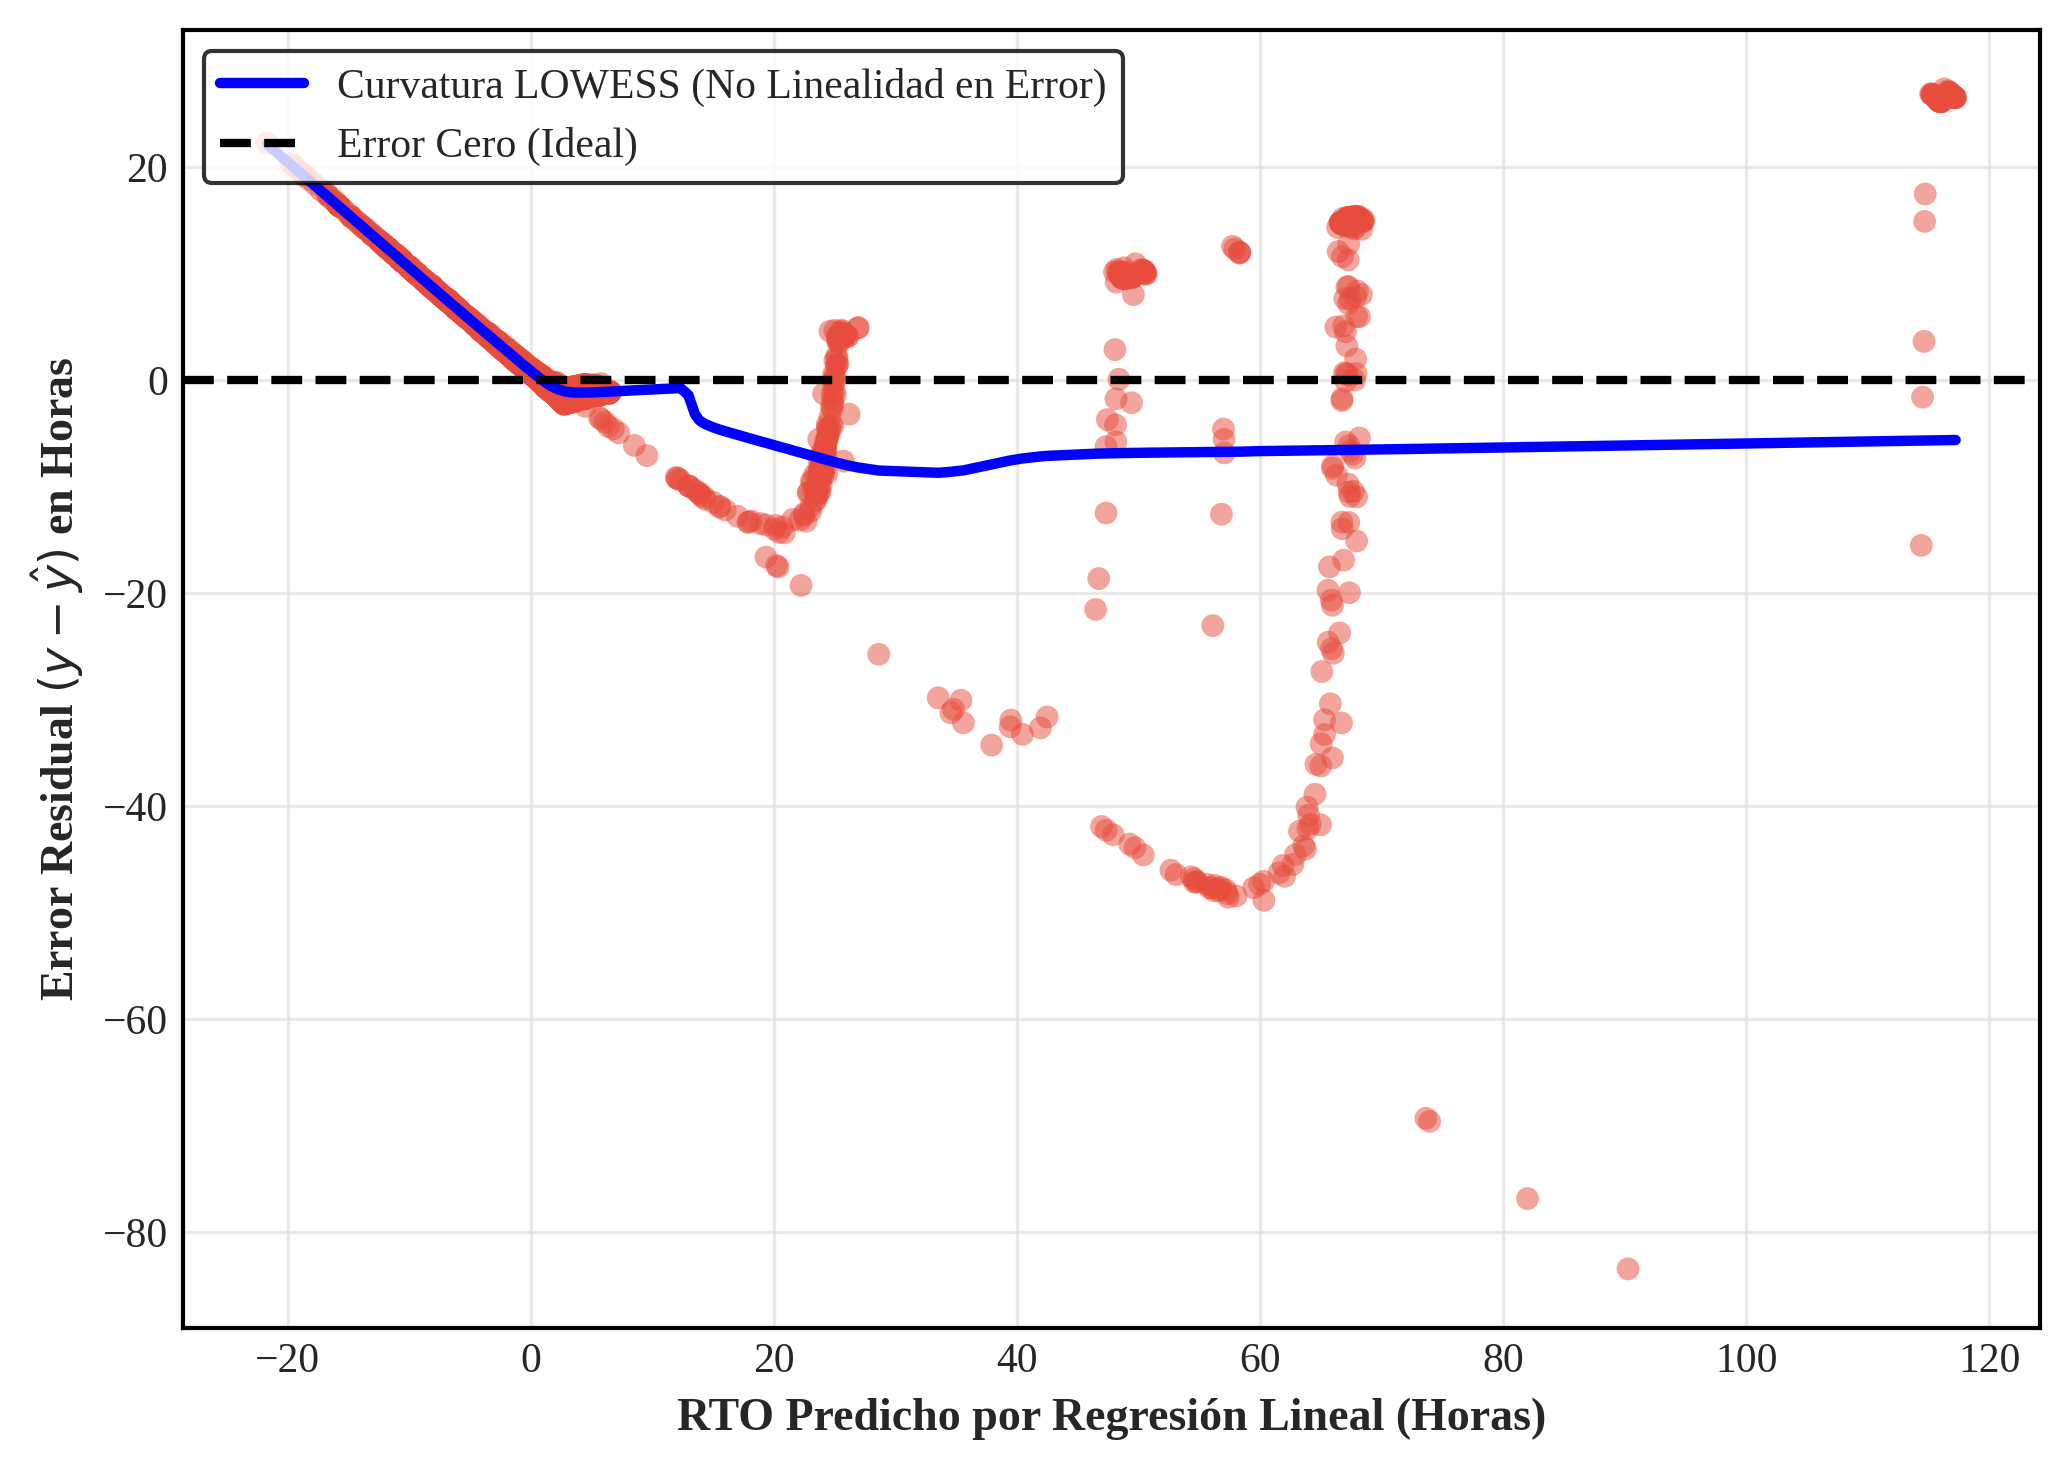

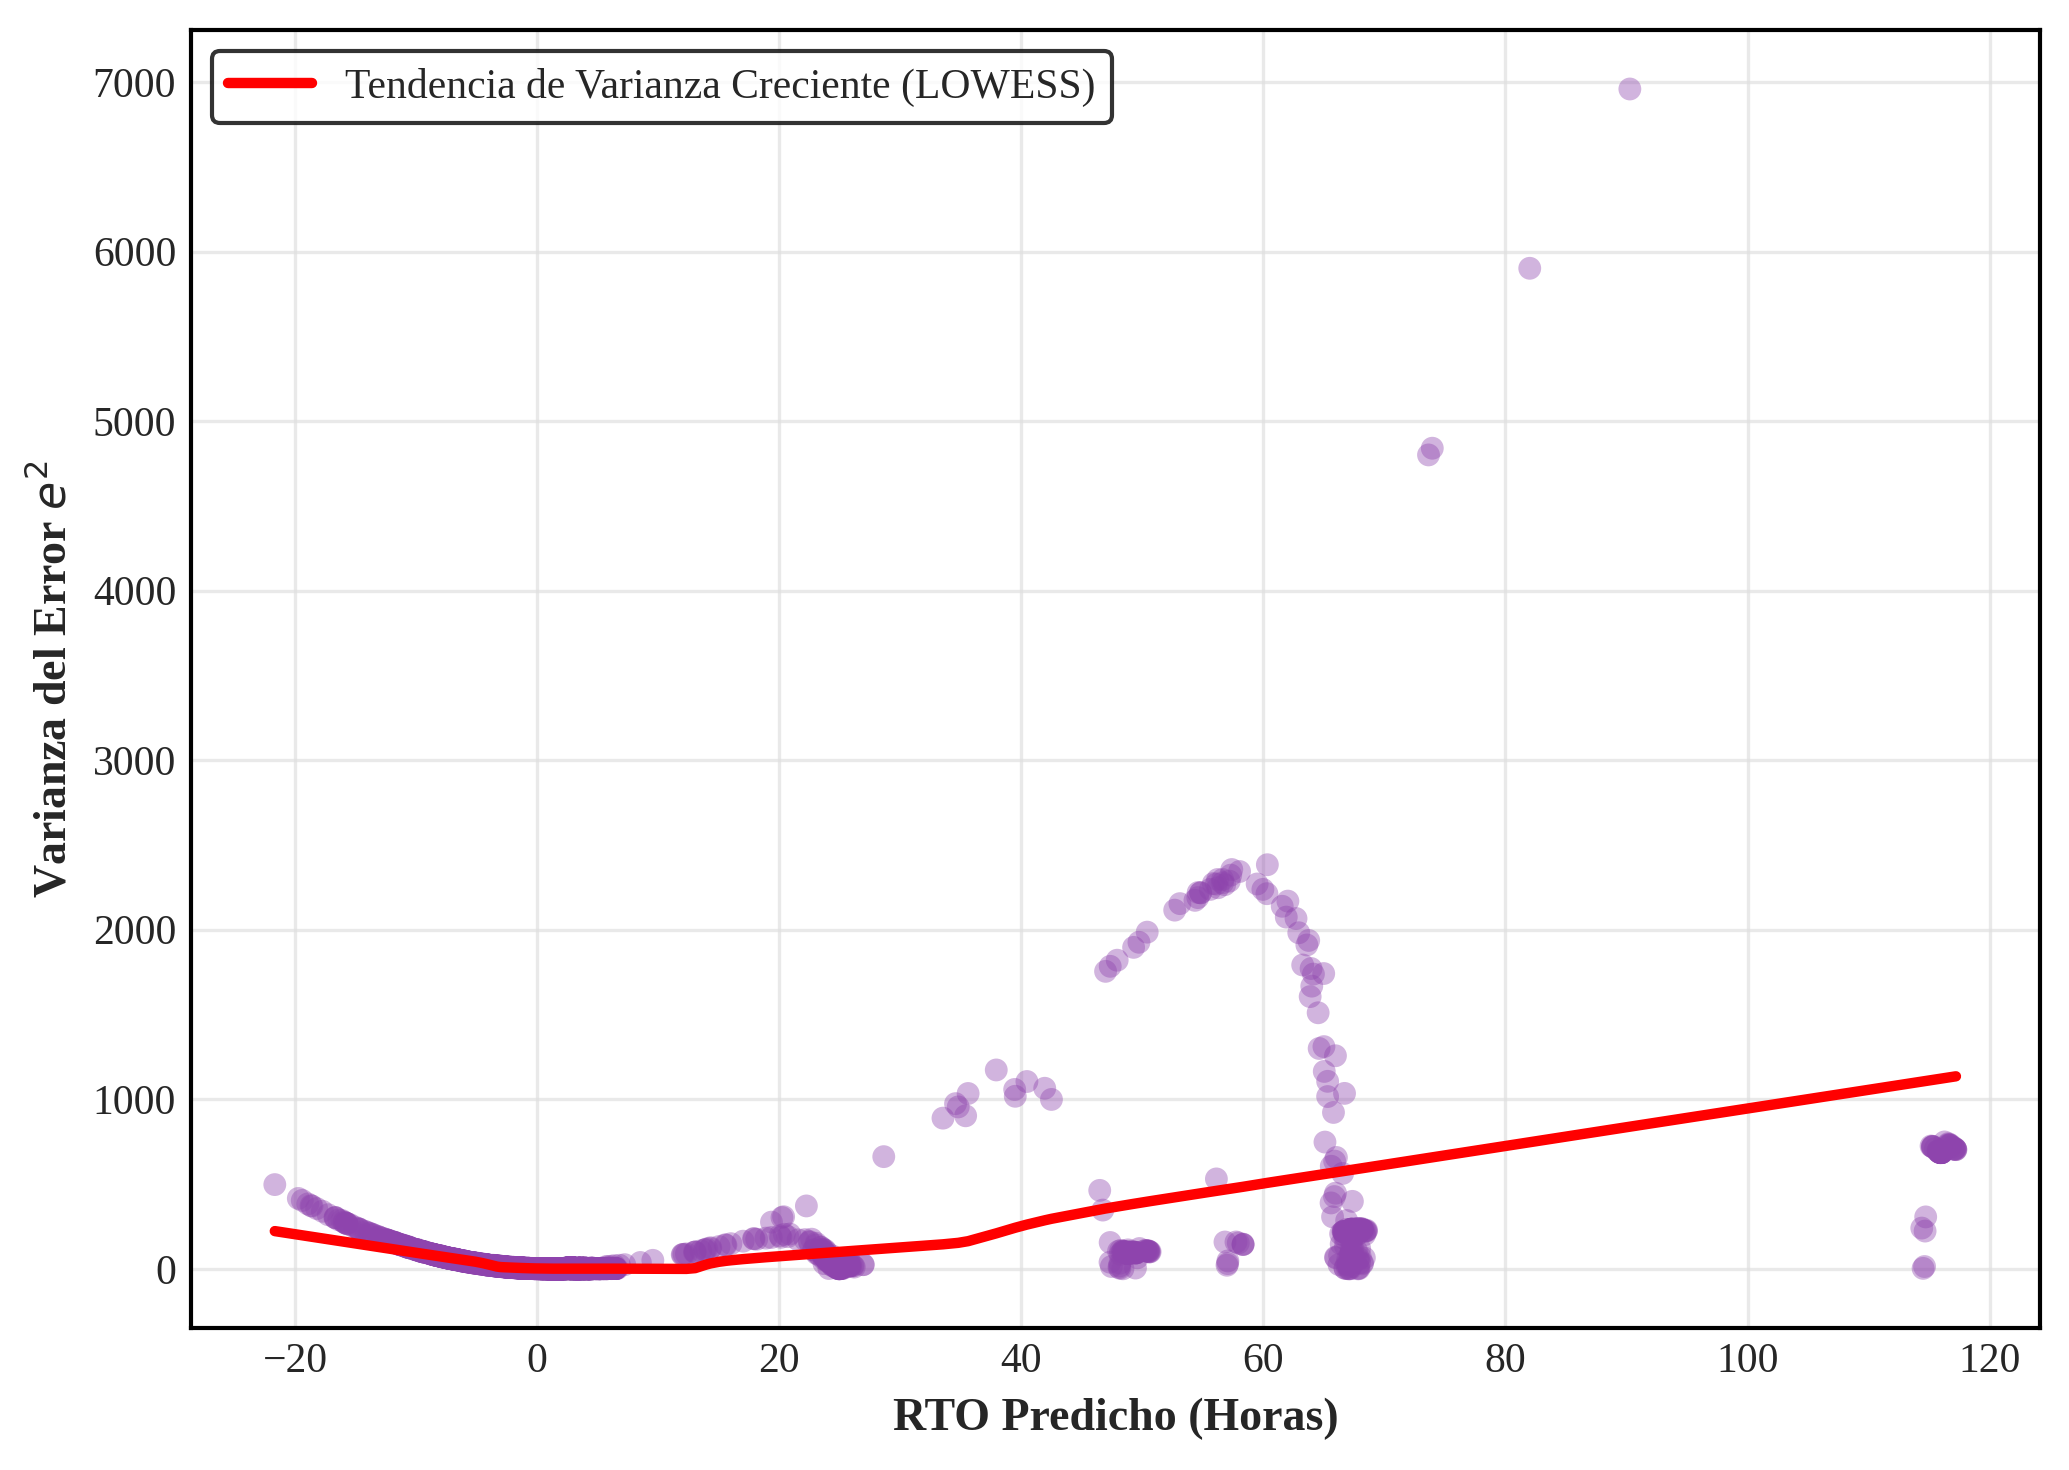


4. DIAGNÓSTICO DE INTERACCIÓN Y MULTICOLINEALIDAD



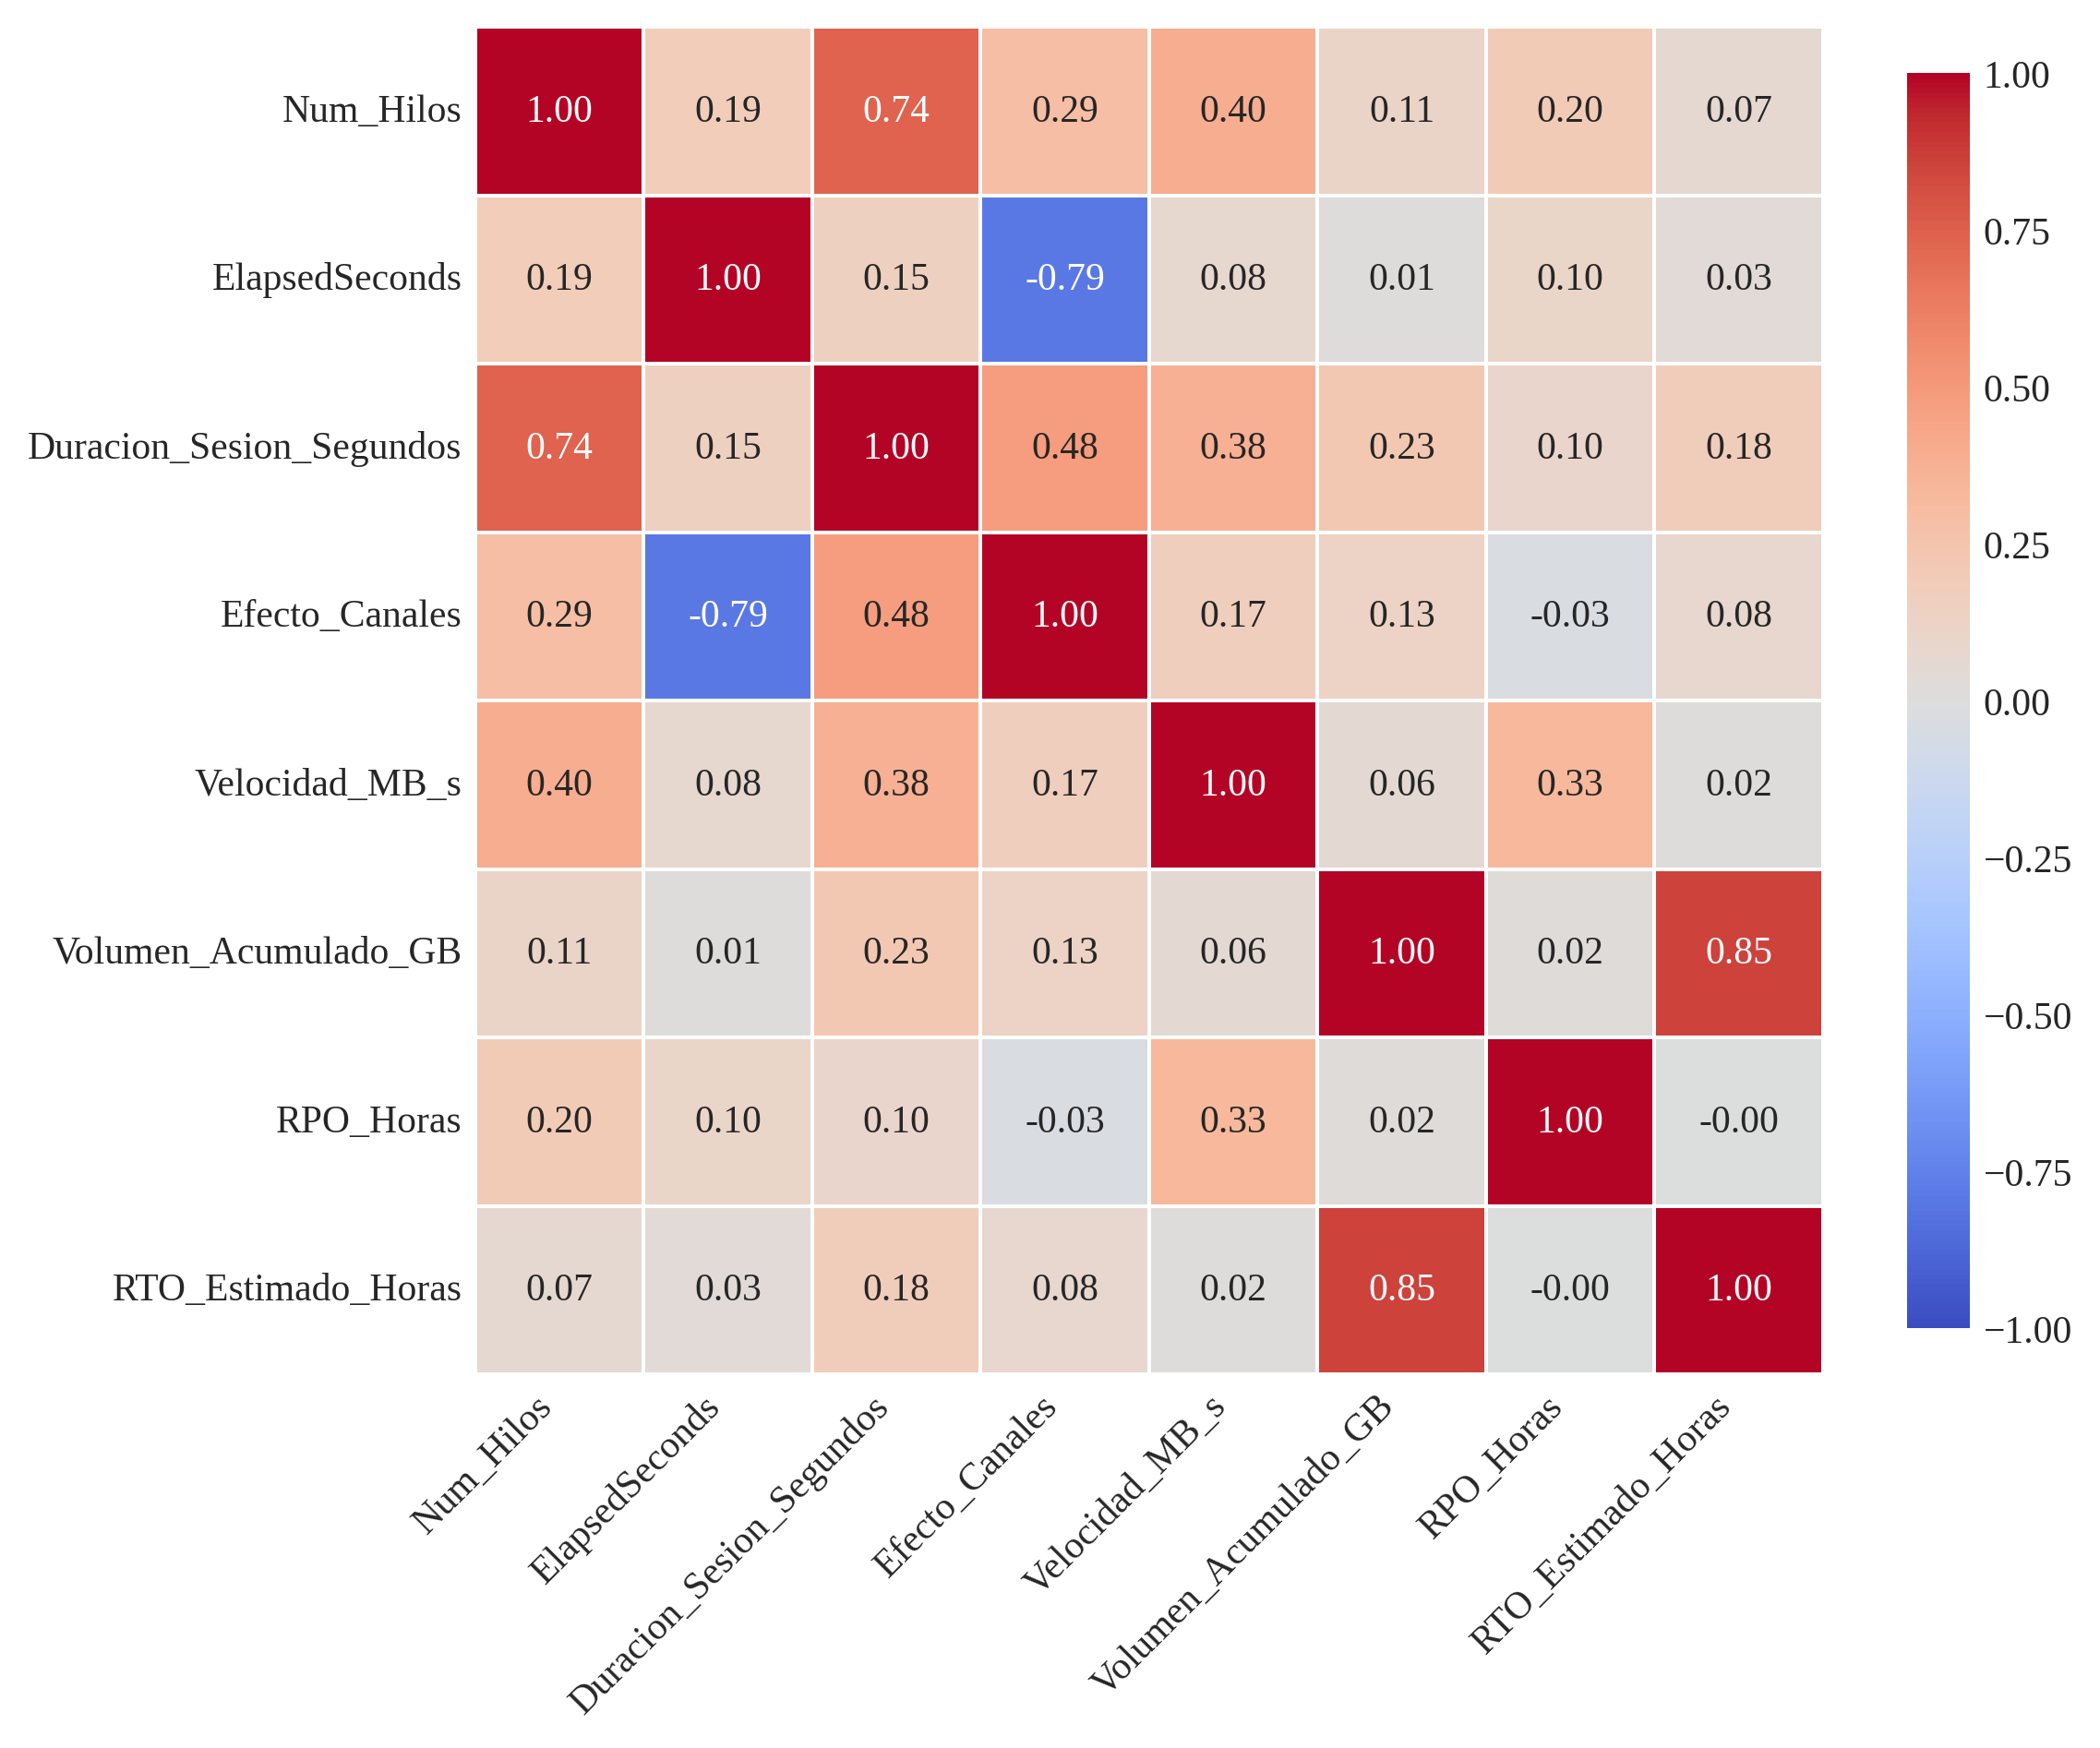


5. RESULTADOS DE NEGOCIO (SENSIBILIDAD FINANCIERA)

-> SENSIBILIDAD (RECALL) PARA DETECTAR RIESGOS DORA: 96.97%
Justificación: Se prioriza la minimización de Falsos Negativos (Peligro Oculto).



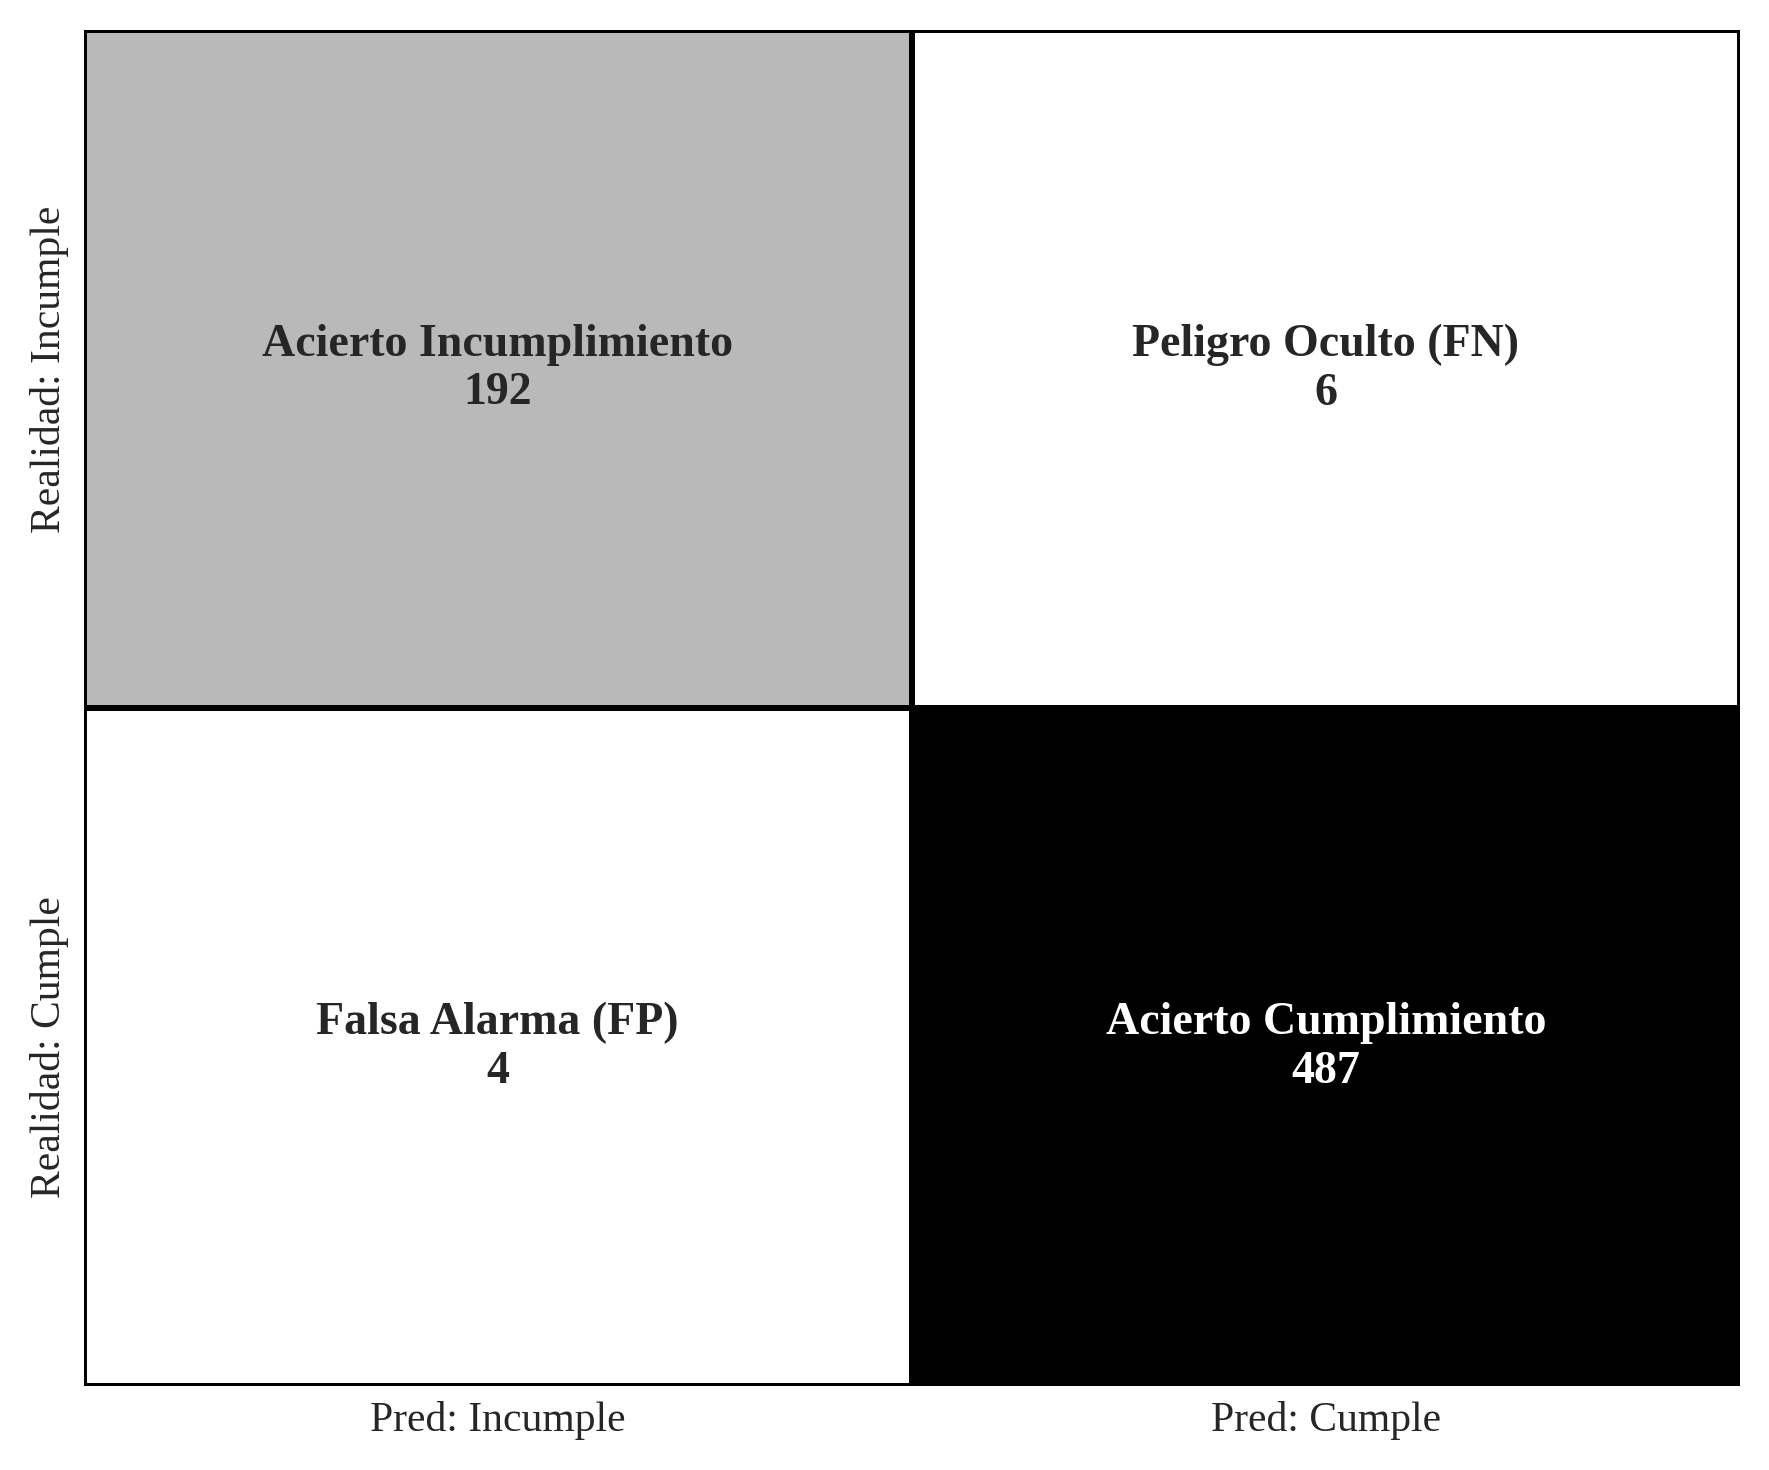


6. EVALUACIÓN COMPARATIVA: ML vs ENFOQUE LINEAL



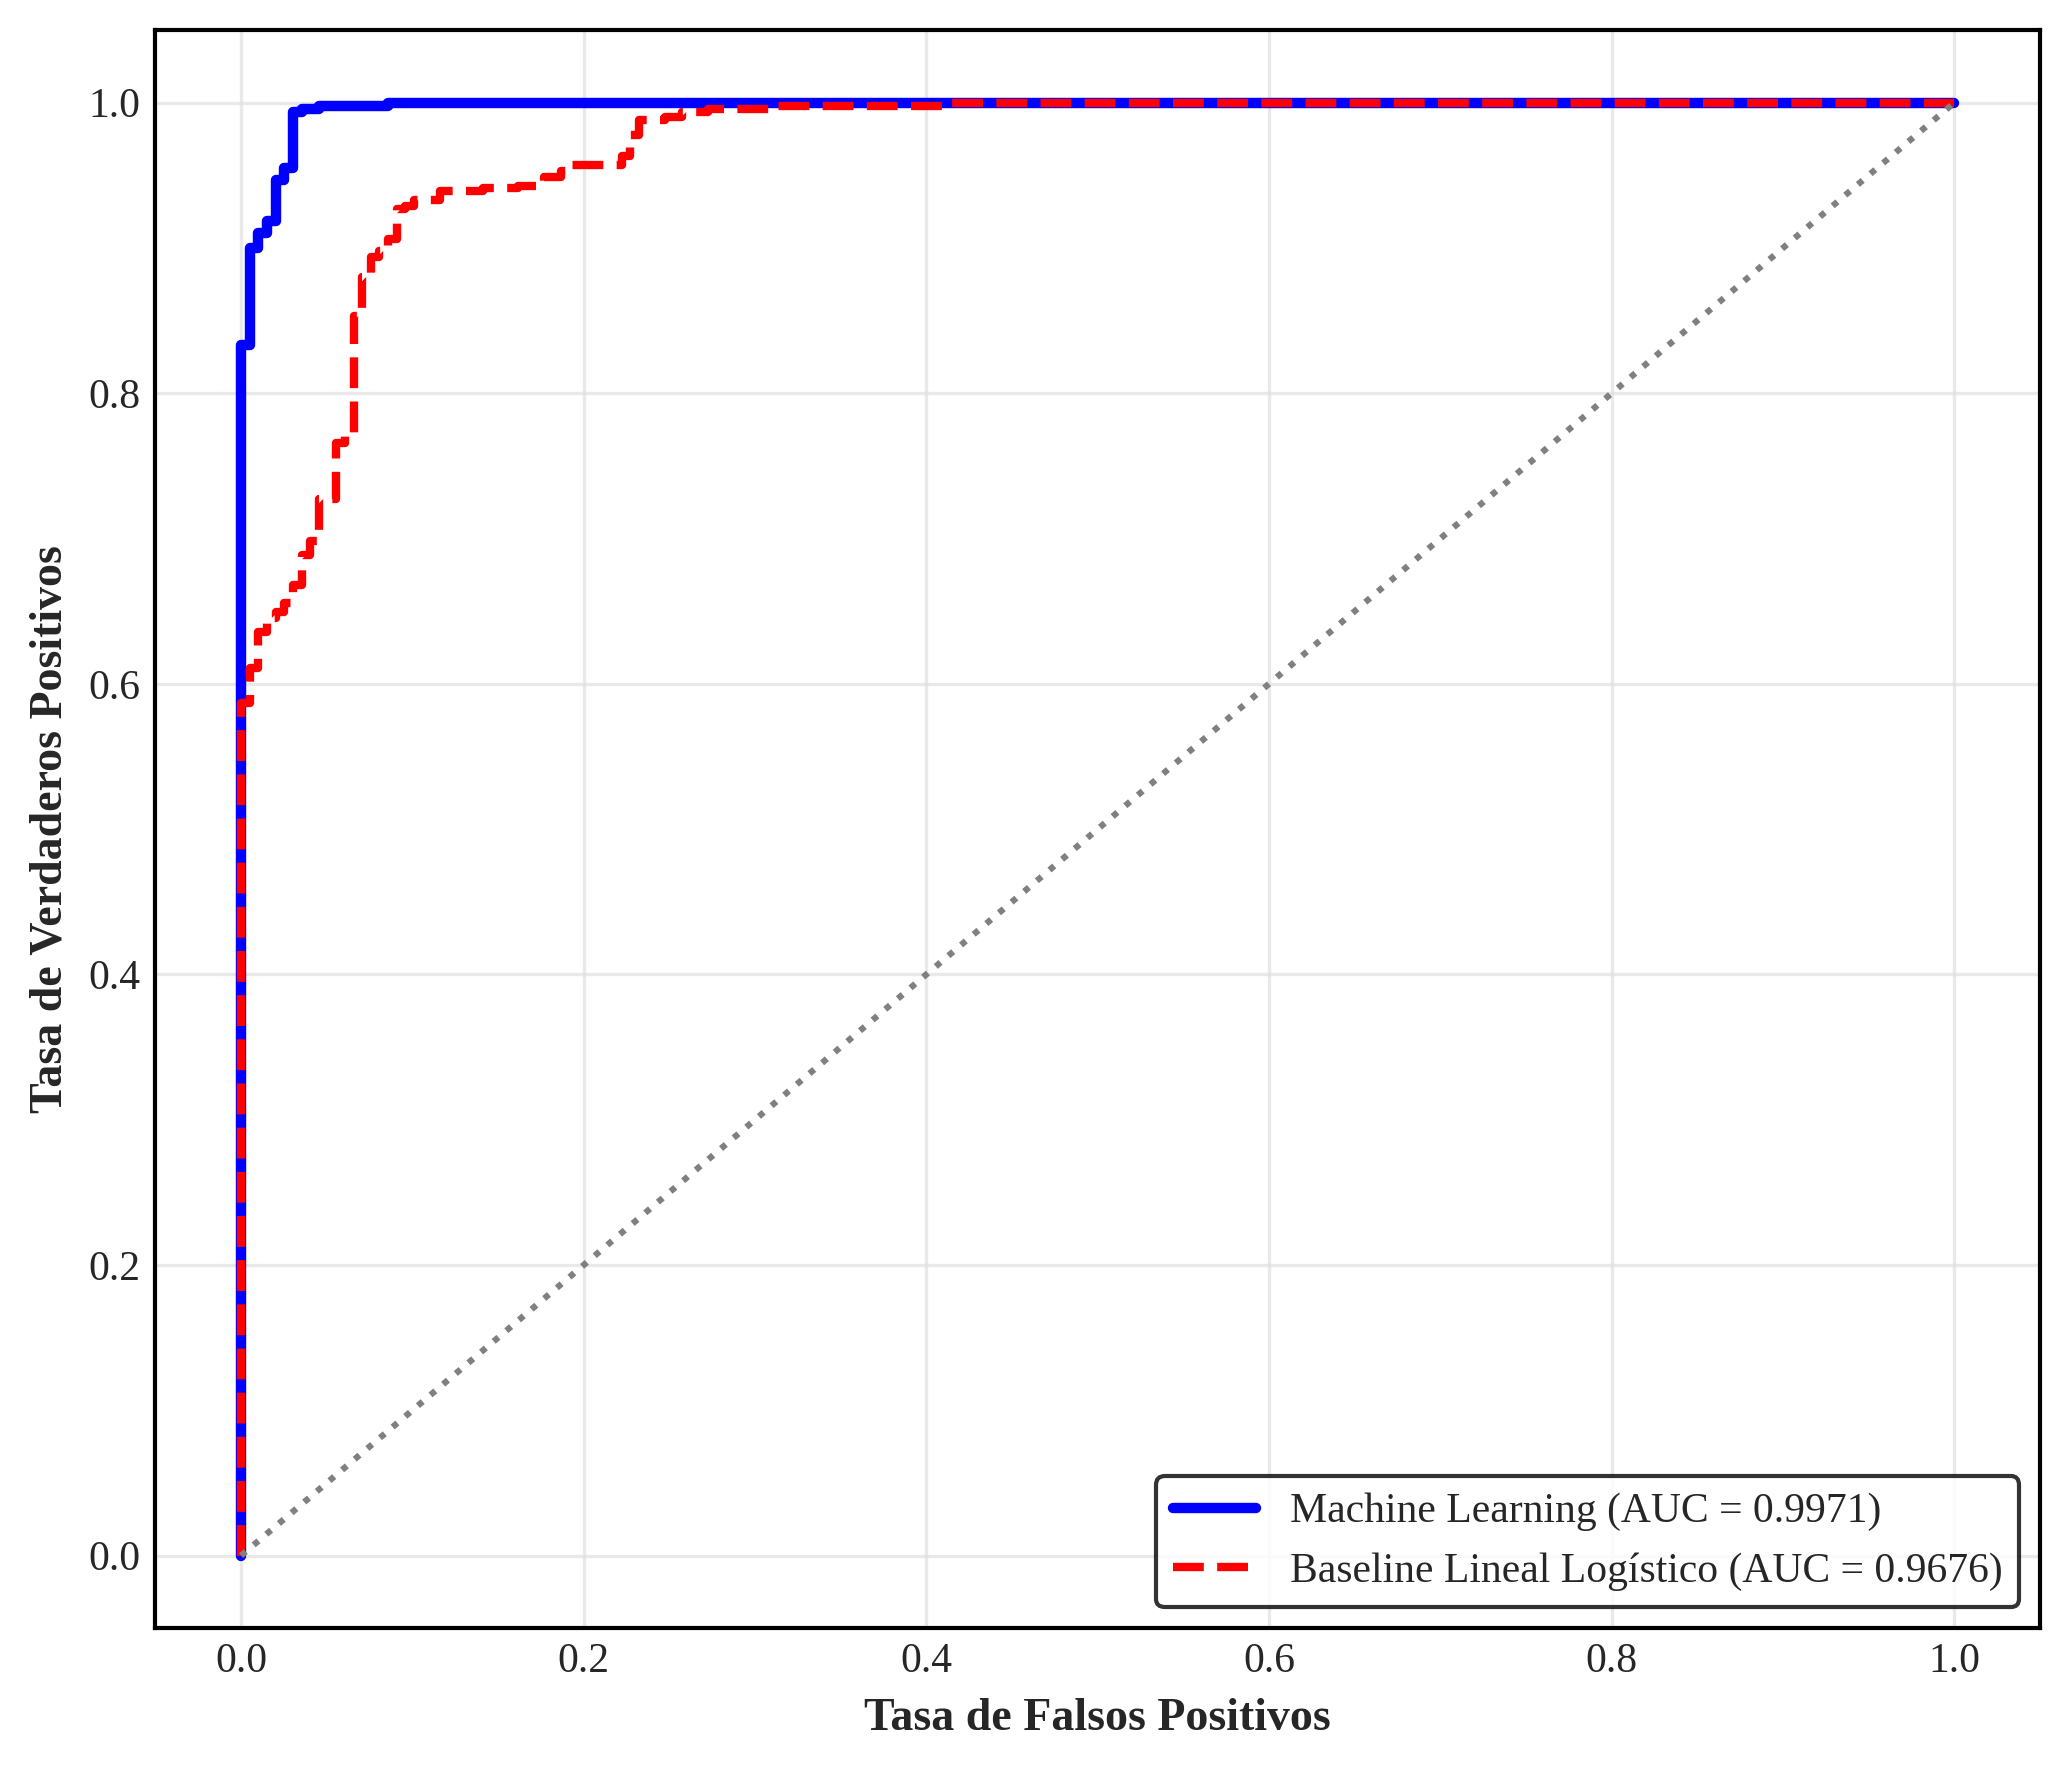

Mejora neta del Machine Learning sobre el enfoque lineal: +0.0295 AUC


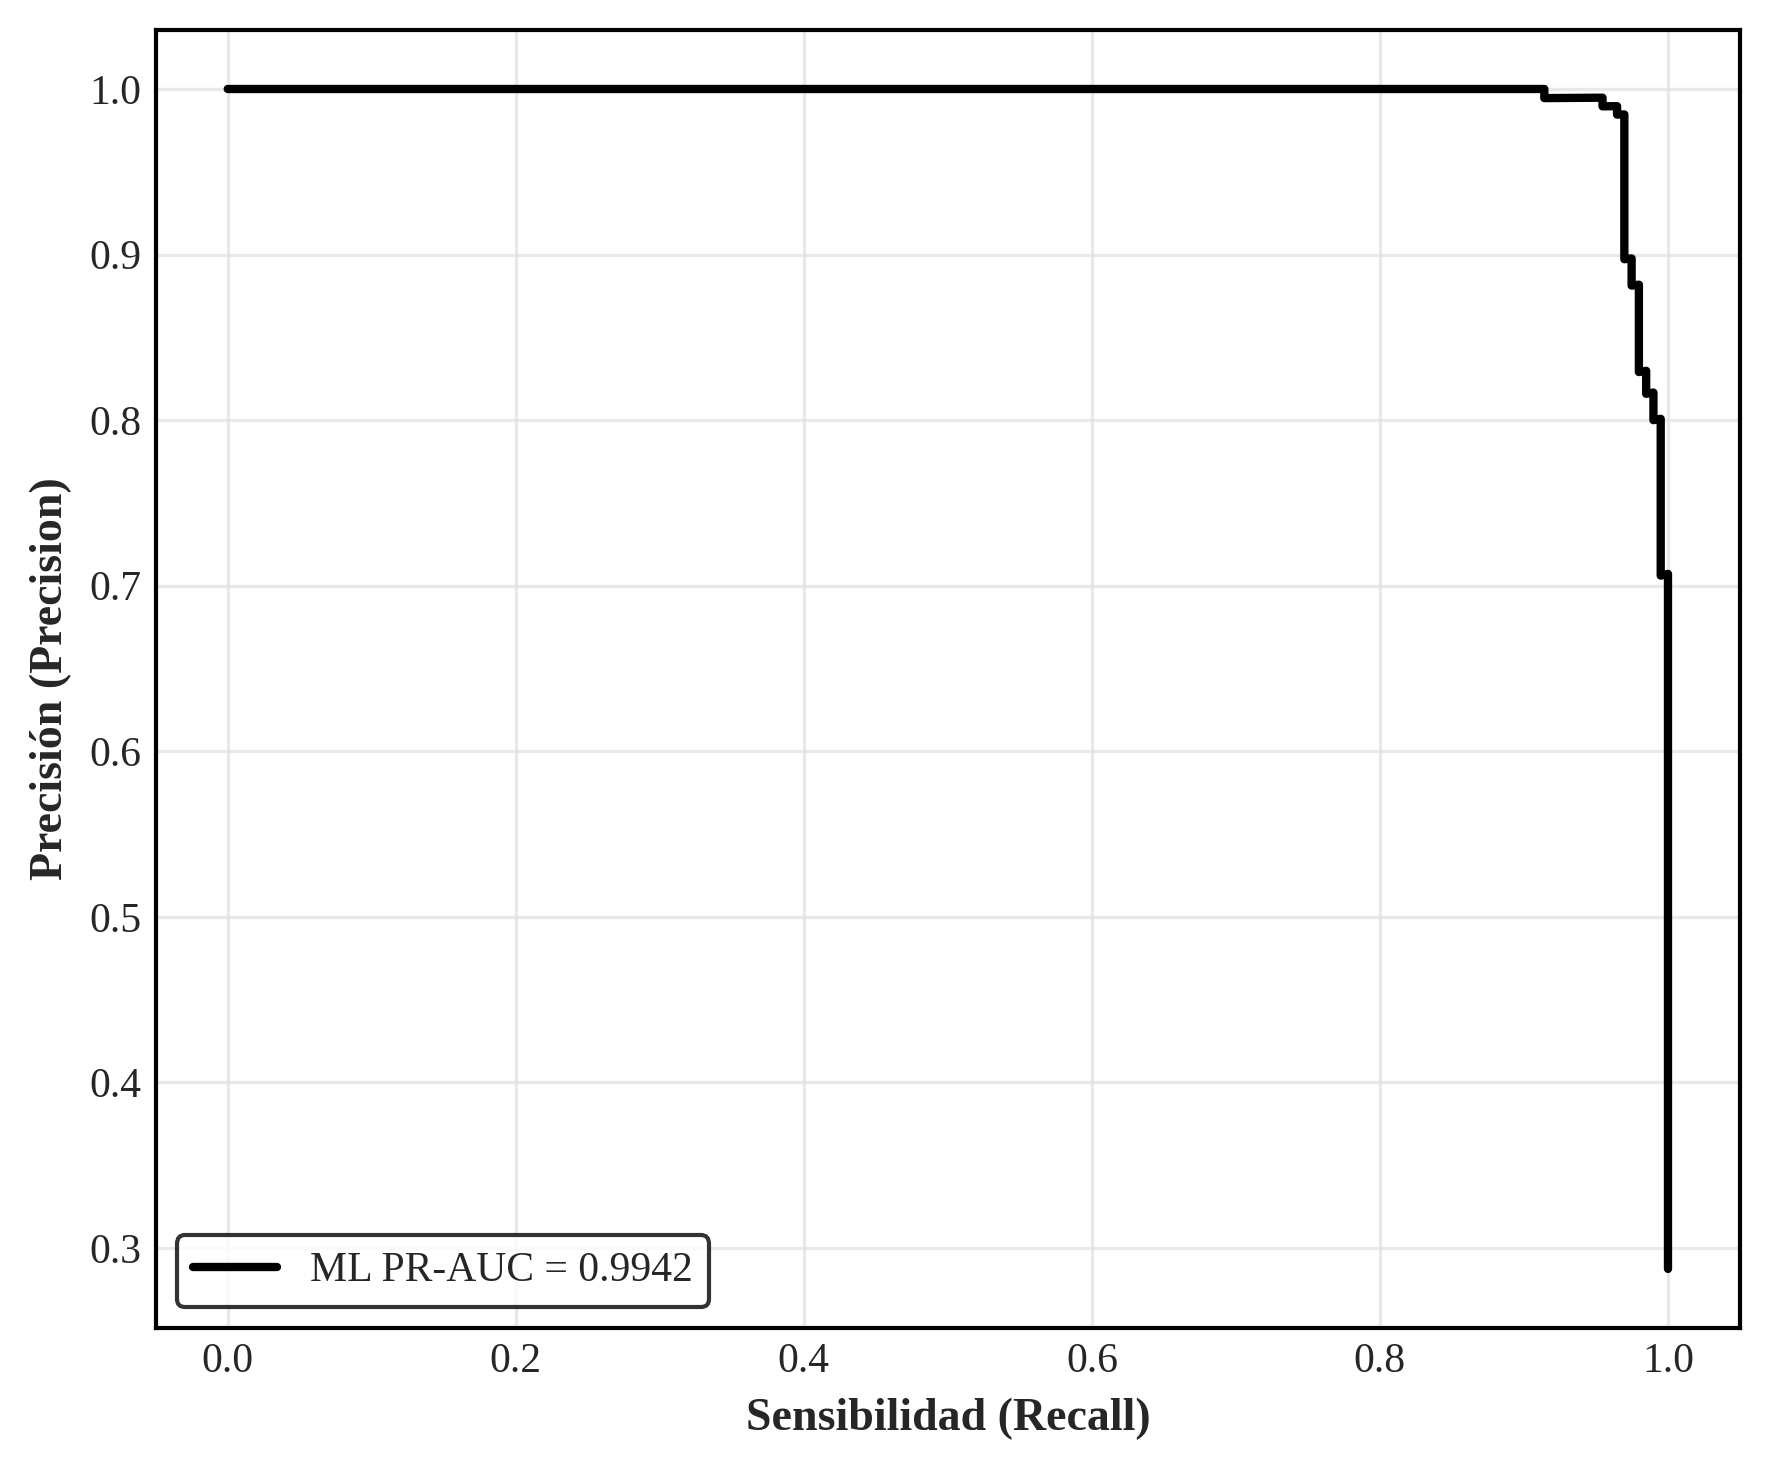


7. EXPLICABILIDAD DEL MODELO



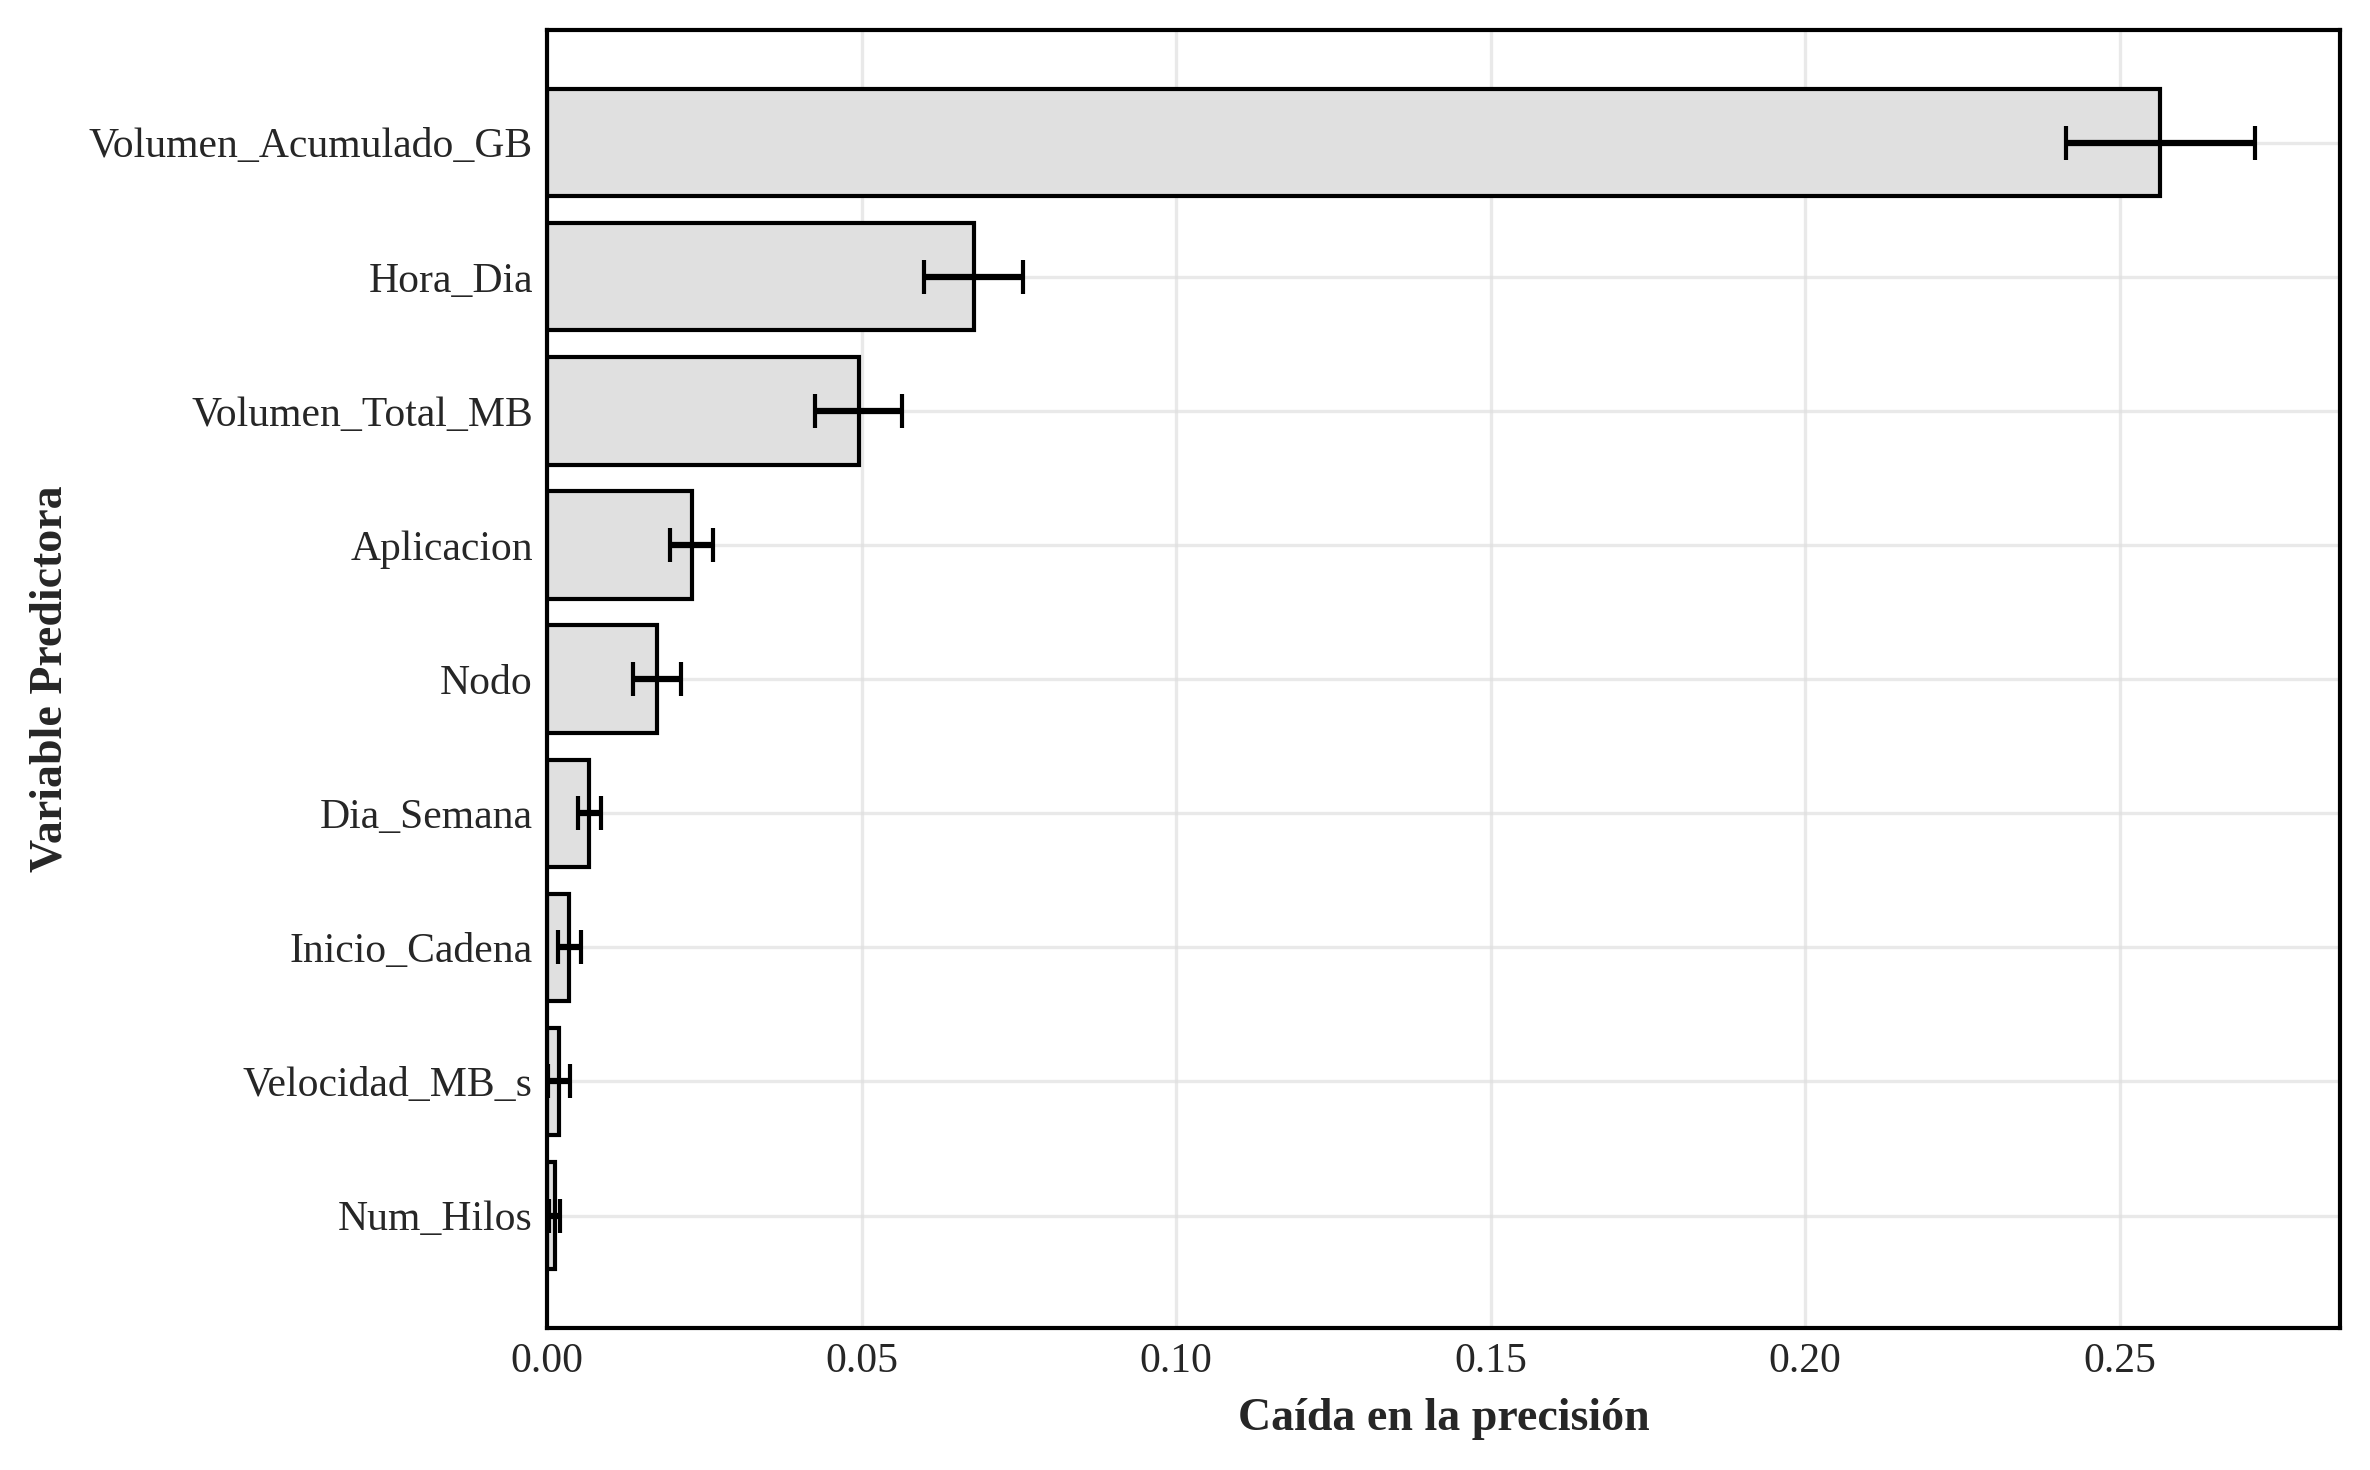


CONCLUSIÓN: El modelo logró abstraer matemáticamente las relaciones complejas y no lineales sin depender de variables determinísticas.


In [2]:
# =============================================================================
# [CELDA 1: MARKDOWN]
# =============================================================================
"""
# Fase de Modelado (CRISP-DM): Predicción de SLAs con Machine Learning

**Objetivo:** Entrenar, validar y explicar el modelo de Machine Learning definitivo para la predicción de resiliencia operativa en bases de datos Oracle RAC.

El análisis exploratorio evidencia que el fenómeno presenta un comportamiento no lineal, con alta varianza y dependencias entre variables operativas como volumen y rendimiento de red. Estas características limitan la capacidad de los modelos paramétricos tradicionales, los cuales asumen relaciones lineales y varianza constante.

Para validar esta hipótesis, se compararon distintos enfoques (modelos lineales, determinísticos y algoritmos de Machine Learning), evidenciando que los modelos basados en árboles de decisión presentan una mayor capacidad de generalización y discriminación, reflejada en métricas superiores de desempeño (ROC-AUC y Precision-Recall).

En consecuencia, el uso de modelos de Machine Learning no se plantea como una sustitución del enfoque determinístico, sino como un complemento estratégico que permite capturar relaciones complejas y anticipar escenarios de incumplimiento en entornos altamente variables.
"""

# =============================================================================
# [CELDA 2: CÓDIGO] - Configuración Global IEEE y Carga de Datos
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import reset_ramsey

# SciKit-Learn: Modelado y Evaluación
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.inspection import permutation_importance

# --- CONFIGURACIÓN ESTRICTA ESTILO IEEE Y ACADÉMICO (TIPO R/GGPLOT2) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'serif']
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 300

# Aspecto visual tipo "theme_bw" de R
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.color'] = '#E0E0E0'
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '-'

print("1. Cargando el Dataset Consolidado (Pre-depuración de Data Leakage)...")
df = pd.read_csv('Dataset_ML_Clasificacion_SLA_4.csv')

df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Volumen_GB'] = df['Volumen_Total_MB'] / 1024.0

print(f"Dimensiones del Dataset: {df.shape}")


# =============================================================================
# [CELDA 3: MARKDOWN]
# =============================================================================
"""
## X.1 Análisis Exploratorio de Datos (EDA) y Caracterización de la Infraestructura

Previo a la selección y entrenamiento de algoritmos predictivos, se ejecutó un Análisis Exploratorio de Datos (EDA) auxiliado por estadística descriptiva para comprender la naturaleza de la telemetría operativa extraída de la arquitectura *Oracle RMAN*.

El análisis visual de las distribuciones volumétricas mediante diagramas de cajas (*Boxplots*) en escala logarítmica evidenció una varianza extrema en los tamaños de los respaldos dependiendo de su tipo (FULL, ARCHIVE, DIFERENCIAL). Asimismo, la proyección cronológica de la velocidad efectiva de la red (*Throughput*) reveló un patrón altamente estocástico y de "diente de sierra". Esta volatilidad confirma que el rendimiento de la infraestructura no es un factor constante, sino que está sometido a fluctuaciones operativas, congestión y contención de I/O.
"""

# =============================================================================
# [CELDA 4: CÓDIGO] - EDA: Estadística Descriptiva y Gráficos Visuales
# =============================================================================
print("\n====================================================================")
print("1. ANÁLISIS EXPLORATORIO DE DATOS (EDA) Y ESTADÍSTICA DESCRIPTIVA")
print("====================================================================\n")

print("--- Resumen Estadístico de Variables Continuas Clave ---")
columnas_numericas = ['Volumen_GB', 'Velocidad_MB_s', 'Duracion_Sesion_Segundos']
print(df[columnas_numericas].describe().round(2).to_string())

# ---------------------------------------------------------
# FIGURA EDA 1: DIAGRAMA DE CAJAS (Boxplot Logarítmico)
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='ScheduleLabel', y='Volumen_GB', hue='ScheduleLabel',
            palette="dark", showmeans=True, legend=False,
            meanprops={"marker":"^","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"})

# Ejes sin título para inclusión en Word
plt.xlabel('Tipo de Programación', fontweight='bold')
plt.ylabel('Volumen Transferido (GB)', fontweight='bold')
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURA EDA 2: VOLATILIDAD TEMPORAL DE LA RED
# ---------------------------------------------------------
df_sorted = df.sort_values('Start_Time')

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_sorted, x='Start_Time', y='Velocidad_MB_s',
             color='black', alpha=0.2, linewidth=1.0, zorder=1)

sns.scatterplot(data=df_sorted, x='Start_Time', y='Velocidad_MB_s',
                hue='ScheduleLabel', style='ScheduleLabel', palette='dark',
                alpha=0.8, s=40, edgecolor='black', zorder=2)

plt.xlabel('Línea Temporal Dinámica', fontweight='bold')
plt.ylabel('Rendimiento Efectivo (MB/s)', fontweight='bold')
plt.axhline(df['Velocidad_MB_s'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Media Global: {df['Velocidad_MB_s'].mean():.1f} MB/s", zorder=3)

# Leyenda unificada con marco negro
legend = plt.legend(title='Tipo de Respaldo', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
legend.get_frame().set_edgecolor('black')
plt.grid(True)
plt.tight_layout()
plt.show()


# =============================================================================
# [CELDA 5: MARKDOWN]
# =============================================================================
"""
## X.2 Justificación Matemática: No Linealidad y Heterocedasticidad

Validando los hallazgos del EDA, se analizó matemáticamente el comportamiento físico del Tiempo de Recuperación Objetivo (RTO).

* **No Linealidad (Test de Ramsey RESET):** Se observa un comportamiento curvo en los datos. Esto se demuestra mediante la discrepancia entre las correlaciones de Pearson y Spearman, el análisis gráfico de residuos (presencia de patrones curvos en LOWESS) y la significancia estadística del test econométrico de Ramsey RESET.
* **Heterocedasticidad (Test de Breusch-Pagan):** La varianza del error no es constante; se dispersa (efecto embudo) a medida que aumentan los tiempos predichos.
Ambos fenómenos invalidan matemáticamente la robustez de las estimaciones lineales y fundamentan el salto hacia la Inteligencia Artificial.
"""

# =============================================================================
# [CELDA 6: CÓDIGO] - Análisis de No Linealidad y Heterocedasticidad
# =============================================================================
print("====================================================================")
print("2. COMPORTAMIENTO FÍSICO: NO LINEALIDAD Y ESTIMADOR BASE")
print("====================================================================\n")

# Simulamos el RTO real sometido a la fluctuación de la red
vel_minima = max(df['Velocidad_MB_s'].quantile(0.05), 5.0)
vel_real_gb_h = df['Velocidad_MB_s'].clip(lower=vel_minima) * 3600.0 / 1024.0
df['RTO_Real_Volatil'] = (df['Volumen_Acumulado_GB'] / (vel_real_gb_h * 0.8)) + 0.5

# A. PRUEBA DE CORRELACIONES (Pearson vs Spearman)
pearson = df[['Volumen_Acumulado_GB', 'RTO_Real_Volatil']].corr(method='pearson').iloc[0,1]
spearman = df[['Volumen_Acumulado_GB', 'RTO_Real_Volatil']].corr(method='spearman').iloc[0,1]

print("A. Análisis de Correlaciones (Volumen vs RTO Real):")
print(f"   -> Pearson (Lineal estricta): {pearson:.3f}")
print(f"   -> Spearman (Monótona/Curva): {spearman:.3f}")
if spearman > pearson:
    print("   [!] Conclusión: Como Spearman > Pearson, la relación es monótona pero NO estrictamente lineal.\n")

# ---------------------------------------------------------
# FIGURA: NO LINEALIDAD VISUAL (Volumen vs RTO)
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='Volumen_Acumulado_GB', y='RTO_Real_Volatil',
            scatter_kws={'alpha': 0.4, 's': 20, 'edgecolor': 'none', 'color': '#2980B9'},
            line_kws={'color': 'red', 'linewidth': 2.5, 'label': 'Tendencia Suavizada (LOWESS)'},
            lowess=True)

plt.xlabel('Volumen Acumulado a Restaurar (GB)', fontweight='bold')
plt.ylabel('RTO Real Volátil (Horas)', fontweight='bold')
plt.legend(loc='upper left', frameon=True).get_frame().set_edgecolor('black')
plt.tight_layout()
plt.show()

# Ajuste del Modelo OLS
X_ols = df[['Volumen_Acumulado_GB', 'Velocidad_MB_s']].fillna(0)
X_ols = sm.add_constant(X_ols)
y_ols = df['RTO_Real_Volatil'].fillna(0)
modelo_ols = sm.OLS(y_ols, X_ols).fit()

print("====================================================================")
print("3. DIAGNÓSTICO MATEMÁTICO: RESET TEST Y HETEROCEDASTICIDAD")
print("====================================================================\n")

# B. RAMSEY RESET TEST (Prueba econométrica oficial de no linealidad)
try:
    resultado_reset = reset_ramsey(modelo_ols, degree=2)
    print(f"B. Test de Ramsey RESET (Especificación Lineal): F={resultado_reset.fvalue:.2f}, p-value={resultado_reset.pvalue:.6e}")
    if resultado_reset.pvalue < 0.05:
        print("   [!] Se rechaza H0: El modelo lineal omite variables no lineales. La relación es definitivamente curva.\n")
except Exception as e:
    print("Test de Ramsey no aplicable a este ensamble particular.\n")

# C. TEST DE BREUSCH-PAGAN (Heterocedasticidad)
bp_test = sms.het_breuschpagan(modelo_ols.resid, modelo_ols.model.exog)
print(f"C. Test de Breusch-Pagan (Varianza del Error): LM={bp_test[0]:.2f}, p-value={bp_test[1]:.6e}")
if bp_test[1] < 0.05:
    print("   [!] Se rechaza H0: Existe HETEROCEDASTICIDAD significativa en el modelo lineal.")

df['RTO_Predicho_Lineal'] = modelo_ols.predict(X_ols)
df['Error_Residual'] = y_ols - df['RTO_Predicho_Lineal']
df['Varianza_Error_Cuadratico'] = df['Error_Residual']**2

# ---------------------------------------------------------
# FIGURA: RESIDUOS (Curvatura No Lineal y Heterocedasticidad)
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='RTO_Predicho_Lineal', y='Error_Residual',
            scatter_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'none', 'color': '#E74C3C'},
            line_kws={'color': 'blue', 'linewidth': 2.5, 'label': 'Curvatura LOWESS (No Linealidad en Error)'},
            lowess=True)

plt.axhline(0, color='black', linestyle='--', linewidth=2, label='Error Cero (Ideal)')
plt.xlabel('RTO Predicho por Regresión Lineal (Horas)', fontweight='bold')
plt.ylabel(r'Error Residual $(y - \hat{y})$ en Horas', fontweight='bold')
plt.legend(loc='upper left', frameon=True).get_frame().set_edgecolor('black')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FIGURA: VARIANZA DEL ERROR CUADRÁTICO
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='RTO_Predicho_Lineal', y='Varianza_Error_Cuadratico',
            scatter_kws={'alpha': 0.4, 's': 30, 'edgecolor': 'none', 'color': '#8E44AD'},
            line_kws={'color': 'red', 'linewidth': 2.5, 'label': 'Tendencia de Varianza Creciente (LOWESS)'},
            lowess=True)

plt.xlabel('RTO Predicho (Horas)', fontweight='bold')
plt.ylabel(r'Varianza del Error $e^2$', fontweight='bold')
plt.legend(loc='upper left', frameon=True).get_frame().set_edgecolor('black')
plt.tight_layout()
plt.show()


# =============================================================================
# [CELDA 7: CÓDIGO] - Matriz de Correlación
# =============================================================================
print("\n====================================================================")
print("4. DIAGNÓSTICO DE INTERACCIÓN Y MULTICOLINEALIDAD")
print("====================================================================\n")

columnas_num_eda = [
    'Num_Hilos', 'ElapsedSeconds', 'Duracion_Sesion_Segundos',
    'Efecto_Canales', 'Velocidad_MB_s', 'Volumen_Acumulado_GB',
    'RPO_Horas', 'RTO_Estimado_Horas'
]

plt.figure(figsize=(8, 7))
corr_matrix = df[columnas_num_eda].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": .8}, linewidths=0.5, linecolor='white')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# =============================================================================
# [CELDA 8: MARKDOWN]
# =============================================================================
"""
## X.3 Entrenamiento del Modelo (Machine Learning)

Dado que se comprobó la inestabilidad de los modelos lineales y determinísticos, se procede a estructurar la clasificación utilizando `HistGradientBoostingClassifier`, un algoritmo basado en árboles de decisión capaz de capturar interacciones no lineales sin presuponer distribuciones paramétricas.
"""

# =============================================================================
# [CELDA 9: CÓDIGO] - Estructuración de X (Predictoras) y Y (Target)
# =============================================================================
y = df['Cumple_SLA']

columnas_a_eliminar = [
    'Grupo_Sesion_ID', 'JobID', 'BackupID', 'Cadena_ID', 'Start_Time', 'Expire_Time', 'Volumen_GB',
    'Umbral_RPO_Horas', 'Umbral_RTO_Horas', 'ElapsedSeconds',
    'SLA_RPO_Cumple', 'SLA_RTO_Cumple', 'Riesgo_Total_COP', 'Cumple_SLA',
    'RPO_Horas', 'RTO_Estimado_Horas',
    'RTO_Real_Volatil', 'RTO_Predicho_Lineal', 'Error_Residual', 'Varianza_Error_Cuadratico'
]

X = df.drop(columns=columnas_a_eliminar, errors='ignore')


# =============================================================================
# [CELDA 10: CÓDIGO] - Entrenamiento (ML vs Baseline Lineal) y Matriz de Confusión
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

variables_texto = ['Nodo', 'Aplicacion', 'ScheduleLabel']
preprocesador = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), variables_texto)],
    remainder='passthrough'
)

# 1. Modelo de Machine Learning (Propuesto)
pipeline_ml = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('clasificador', HistGradientBoostingClassifier(random_state=42, max_iter=200, early_stopping=True, validation_fraction=0.1))
])
pipeline_ml.fit(X_train, y_train)
y_pred_ml = pipeline_ml.predict(X_test)

# 2. Modelo Baseline Lineal (Regresión Logística para la comparación de curvas ROC)
pipeline_baseline = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('escalador', StandardScaler(with_mean=False)),
    ('clasificador', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
pipeline_baseline.fit(X_train, y_train)

# --- MATRIZ DE CONFUSIÓN DEL ML ---
cm = confusion_matrix(y_test, y_pred_ml)
tp_falla = cm[0, 0]; fn_falla = cm[0, 1]
fp_falla = cm[1, 0]; tn_falla = cm[1, 1]

recall_fallos = tp_falla / (tp_falla + fn_falla)

print("\n====================================================================")
print("5. RESULTADOS DE NEGOCIO (SENSIBILIDAD FINANCIERA)")
print("====================================================================\n")
print(f"-> SENSIBILIDAD (RECALL) PARA DETECTAR RIESGOS DORA: {recall_fallos:.2%}")
print("Justificación: Se prioriza la minimización de Falsos Negativos (Peligro Oculto).\n")

plt.figure(figsize=(6, 5))
nombres_casillas = np.array([
    [f"Acierto Incumplimiento\n{tp_falla}", f"Peligro Oculto (FN)\n{fn_falla}"],
    [f"Falsa Alarma (FP)\n{fp_falla}", f"Acierto Cumplimiento\n{tn_falla}"]
])
sns.heatmap(cm, annot=nombres_casillas, fmt='', cmap='Greys', cbar=False,
            xticklabels=['Pred: Incumple', 'Pred: Cumple'],
            yticklabels=['Realidad: Incumple', 'Realidad: Cumple'],
            annot_kws={"size": 11, "weight": "bold"},
            linewidths=1, linecolor='black')
plt.tight_layout()
plt.show()


# =============================================================================
# [CELDA 11: CÓDIGO] - COMPARACIÓN ROC (El Jaque Mate)
# =============================================================================
print("\n====================================================================")
print("6. EVALUACIÓN COMPARATIVA: ML vs ENFOQUE LINEAL")
print("====================================================================\n")

# Probabilidades de ambos modelos
y_prob_ml = pipeline_ml.predict_proba(X_test)[:, 1]
y_prob_base = pipeline_baseline.predict_proba(X_test)[:, 1]

auc_ml = roc_auc_score(y_test, y_prob_ml)
auc_base = roc_auc_score(y_test, y_prob_base)

# ---------------------------------------------------------
# FIGURA: CURVA ROC COMPARADA
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
fpr_ml, tpr_ml, _ = roc_curve(y_test, y_prob_ml)
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

plt.plot(fpr_ml, tpr_ml, color='blue', linestyle='-', linewidth=2.5, label=f'Machine Learning (AUC = {auc_ml:.4f})')
plt.plot(fpr_base, tpr_base, color='red', linestyle='--', linewidth=2, label=f'Baseline Lineal Logístico (AUC = {auc_base:.4f})')
plt.plot([0, 1], [0, 1], color='#808080', linestyle=':')

plt.xlabel('Tasa de Falsos Positivos', fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos', fontweight='bold')
plt.legend(loc='lower right', frameon=True, edgecolor='black')
plt.tight_layout()
plt.show()

print(f"Mejora neta del Machine Learning sobre el enfoque lineal: +{auc_ml - auc_base:.4f} AUC")

# ---------------------------------------------------------
# FIGURA: CURVA PRECISION-RECALL DEL ML
# ---------------------------------------------------------
# CORRECCIÓN: PR-AUC sobre clase Incumple (clase 0) — métrica robusta a desbalance [38]
# El gráfico muestra precisión-recall sobre la clase minoritaria de interés.
y_prob_ml_pos0 = pipeline_ml.predict_proba(X_test)[:, 0]
precision_test, recall_test, _ = precision_recall_curve(y_test, y_prob_ml_pos0, pos_label=0)
pr_auc_test = auc(recall_test, precision_test)

plt.figure(figsize=(6, 5))
plt.plot(recall_test, precision_test, color='black', linestyle='-', linewidth=2, label=f'ML PR-AUC = {pr_auc_test:.4f}')
plt.xlabel('Sensibilidad (Recall)', fontweight='bold')
plt.ylabel('Precisión (Precision)', fontweight='bold')
plt.legend(loc='lower left', frameon=True, edgecolor='black')
plt.tight_layout()
plt.show()


# =============================================================================
# [CELDA 12: CÓDIGO] - Explicabilidad (Permutation Importance)
# =============================================================================
print("\n====================================================================")
print("7. EXPLICABILIDAD DEL MODELO")
print("====================================================================\n")

resultado_importancia = permutation_importance(
    pipeline_ml, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

importancias = pd.DataFrame({
    'Variable': X_test.columns,
    'Importancia': resultado_importancia.importances_mean,
    'Desviacion': resultado_importancia.importances_std
}).sort_values(by='Importancia', ascending=True)

importancias_utiles = importancias[importancias['Importancia'] > 0.001]

plt.figure(figsize=(8, 5))
plt.barh(importancias_utiles['Variable'], importancias_utiles['Importancia'], xerr=importancias_utiles['Desviacion'], color='#E0E0E0', edgecolor='black', capsize=4)
plt.xlabel('Caída en la precisión', fontweight='bold')
plt.ylabel('Variable Predictora', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCONCLUSIÓN: El modelo logró abstraer matemáticamente las relaciones complejas y no lineales sin depender de variables determinísticas.")

## X.4 Métricas consolidadas en conjunto de prueba (holdout)

Para garantizar trazabilidad de las cifras que se reportan en la Sección V del cuerpo del documento, esta sección consolida en un único bloque las métricas de evaluación del modelo `HistGradientBoostingClassifier` sobre el conjunto de prueba estratificado (20% del dataset, no visto durante el entrenamiento). Las métricas incluidas siguen el estándar recomendado por Saito y Rehmsmeier [38] para clasificadores binarios sobre datasets desbalanceados: además del ROC-AUC tradicional, se reporta PR-AUC, F1-Score y el `classification_report` desglosado por clase, métricas más informativas ante el desbalance observado en la variable objetivo `Cumple_SLA`. La explicabilidad por importancia de permutación [39] complementa el análisis cuantitativo con la interpretación causal del modelo.

In [3]:
# =============================================================================
# [CELDA 13: CÓDIGO] — Métricas consolidadas en holdout para reporte académico
# =============================================================================
# Este bloque consolida todas las métricas del modelo HistGradientBoosting
# entrenado en la Celda 10. Produce las cifras exactas que se citan en la
# Sección V del documento.

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

print("=" * 70)
print("RESUMEN CONSOLIDADO DE MÉTRICAS — MODELO HistGradientBoosting")
print("Conjunto de prueba (holdout) — 20% del dataset, estratificado")
print("=" * 70)

# --- 1. Caracterización del dataset y split ---
print("\n1. CARACTERIZACIÓN DEL DATASET")
print("-" * 70)
print(f"Sesiones totales              : {len(df):>6,d}")
print(f"Aplicaciones distintas        : {df['Aplicacion'].nunique():>6,d}")
print(f"Sesiones de entrenamiento (80%): {len(X_train):>6,d}")
print(f"Sesiones de prueba (20%)      : {len(X_test):>6,d}")
print(f"Variables predictoras finales : {X.shape[1]:>6,d}")

# --- 2. Distribución de la variable objetivo (desbalance) ---
print("\n2. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (desbalance de clases)")
print("-" * 70)
total_train = len(y_train)
total_test  = len(y_test)
for clase, etiqueta in [(0, "Incumple SLA (clase minoritaria/positiva)"),
                         (1, "Cumple SLA   (clase mayoritaria/negativa)")]:
    n_tr = int((y_train == clase).sum())
    n_te = int((y_test == clase).sum())
    print(f"  {etiqueta}")
    print(f"    Train: {n_tr:>5,d} ({n_tr/total_train:>6.1%})  |  "
          f"Test: {n_te:>4,d} ({n_te/total_test:>6.1%})")

# --- 3. Matriz de confusión (cifras exactas) ---
print("\n3. MATRIZ DE CONFUSIÓN — HistGradientBoosting en holdout")
print("-" * 70)
cm = confusion_matrix(y_test, y_pred_ml)
print(f"                          Pred: Incumple   Pred: Cumple")
print(f"  Real: Incumple (0)      TP = {cm[0,0]:>5d}        FN = {cm[0,1]:>5d}")
print(f"  Real: Cumple   (1)      FP = {cm[1,0]:>5d}        TN = {cm[1,1]:>5d}")
print(f"\n  Total predicciones correctas: {cm[0,0] + cm[1,1]:>4,d}")
print(f"  Total predicciones erróneas : {cm[0,1] + cm[1,0]:>4,d}")

# --- 4. Classification report formal ---
print("\n4. CLASSIFICATION REPORT — desglose por clase")
print("-" * 70)
print(classification_report(y_test, y_pred_ml,
                            target_names=["Incumple SLA (0)", "Cumple SLA (1)"],
                            digits=4))

# --- 5. Métricas agregadas para reporte académico ---
print("5. MÉTRICAS AGREGADAS EN HOLDOUT — para citar en §V del documento")
print("-" * 70)

accuracy   = accuracy_score(y_test, y_pred_ml)
precision_pos = precision_score(y_test, y_pred_ml, pos_label=0)  # clase positiva = INCUMPLE
recall_pos    = recall_score(y_test, y_pred_ml, pos_label=0)
f1_pos        = f1_score(y_test, y_pred_ml, pos_label=0)
f1_weighted   = f1_score(y_test, y_pred_ml, average='weighted')
f1_macro      = f1_score(y_test, y_pred_ml, average='macro')
roc_auc       = roc_auc_score(y_test, y_prob_ml)
# CORRECCIÓN: PR-AUC requiere la probabilidad de la clase pos_label.
# Como pos_label=0 (Incumple), pasamos proba[:, 0] (no [:, 1] que es para clase 1).
y_prob_ml_pos0_tab   = pipeline_ml.predict_proba(X_test)[:, 0]
y_prob_base_pos0_tab = pipeline_baseline.predict_proba(X_test)[:, 0]
pr_auc        = average_precision_score(y_test, y_prob_ml_pos0_tab, pos_label=0)

# Tabla resumen
print(f"  {'Métrica':<35} {'Valor':>10}   Interpretación")
print(f"  {'-'*35} {'-'*10}   {'-'*22}")
print(f"  {'Accuracy global':<35} {accuracy:>10.4f}   Aciertos / total")
print(f"  {'Precision (clase Incumple)':<35} {precision_pos:>10.4f}   1 - falsa alarma")
print(f"  {'Recall / Sensibilidad (Incumple)':<35} {recall_pos:>10.4f}   1 - peligro oculto")
print(f"  {'F1-Score (clase Incumple)':<35} {f1_pos:>10.4f}   Media armónica P-R")
print(f"  {'F1-Score (macro avg)':<35} {f1_macro:>10.4f}   Promedio simple por clase")
print(f"  {'F1-Score (weighted avg)':<35} {f1_weighted:>10.4f}   Ponderado por soporte")
print(f"  {'ROC-AUC':<35} {roc_auc:>10.4f}   Separabilidad de clases")
print(f"  {'PR-AUC (clase Incumple)':<35} {pr_auc:>10.4f}   Robusto a desbalance")

# --- 6. Comparación contra baseline lineal ---
print("\n6. COMPARACIÓN CONTRA BASELINE LINEAL (Regresión Logística)")
print("-" * 70)
y_pred_base = pipeline_baseline.predict(X_test)
f1_base = f1_score(y_test, y_pred_base, pos_label=0)
roc_auc_base = roc_auc_score(y_test, y_prob_base)
pr_auc_base = average_precision_score(y_test, y_prob_base_pos0_tab, pos_label=0)

print(f"  {'Métrica':<25} {'ML (HGB)':>12} {'Baseline':>12} {'Δ':>10}")
print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*10}")
print(f"  {'F1-Score (Incumple)':<25} {f1_pos:>12.4f} {f1_base:>12.4f} {f1_pos-f1_base:>+10.4f}")
print(f"  {'ROC-AUC':<25} {roc_auc:>12.4f} {roc_auc_base:>12.4f} {roc_auc-roc_auc_base:>+10.4f}")
print(f"  {'PR-AUC (Incumple)':<25} {pr_auc:>12.4f} {pr_auc_base:>12.4f} {pr_auc-pr_auc_base:>+10.4f}")

# --- 7. Top-5 variables más explicativas (Permutation Importance) ---
print("\n7. TOP-5 VARIABLES EXPLICATIVAS — Importancia por permutación [39]")
print("-" * 70)
top5 = importancias.sort_values(by='Importancia', ascending=False).head(5)
print(f"  {'#':<3} {'Variable':<35} {'Importancia':>12} {'σ':>10}")
print(f"  {'-'*3} {'-'*35} {'-'*12} {'-'*10}")
for i, (_, fila) in enumerate(top5.iterrows(), 1):
    print(f"  {i:<3} {fila['Variable']:<35} {fila['Importancia']:>12.4f} {fila['Desviacion']:>10.4f}")

# --- 8. Cifras finales para texto del documento ---
print("\n" + "=" * 70)
print("CIFRAS FINALES PARA INSERTAR EN §V DEL DOCUMENTO:")
print("=" * 70)
print(f"""
  Dataset:              {len(df):,} sesiones / 6 apps Oracle RAC
  Split estratificado:  {len(X_train):,} train / {len(X_test):,} test (80/20)
  Desbalance:           {((y == 0).sum()/len(y)):.1%} incumple / {((y == 1).sum()/len(y)):.1%} cumple

  Métricas HistGradientBoosting en holdout:
    • Accuracy:         {accuracy:.4f}
    • Precision (Inc):  {precision_pos:.4f}
    • Recall (Inc):     {recall_pos:.4f}
    • F1 (Inc):         {f1_pos:.4f}
    • F1 weighted:      {f1_weighted:.4f}
    • ROC-AUC:          {roc_auc:.4f}
    • PR-AUC (Inc):     {pr_auc:.4f}

  Ganancia neta sobre baseline lineal:
    • ΔROC-AUC: {roc_auc - roc_auc_base:+.4f}
    • ΔF1:      {f1_pos - f1_base:+.4f}
    • ΔPR-AUC:  {pr_auc - pr_auc_base:+.4f}

  Tres variables más importantes (permutation importance):
    1. {top5.iloc[0]['Variable']}: {top5.iloc[0]['Importancia']:.4f}
    2. {top5.iloc[1]['Variable']}: {top5.iloc[1]['Importancia']:.4f}
    3. {top5.iloc[2]['Variable']}: {top5.iloc[2]['Importancia']:.4f}
""")


RESUMEN CONSOLIDADO DE MÉTRICAS — MODELO HistGradientBoosting
Conjunto de prueba (holdout) — 20% del dataset, estratificado

1. CARACTERIZACIÓN DEL DATASET
----------------------------------------------------------------------
Sesiones totales              :  3,442
Aplicaciones distintas        :      6
Sesiones de entrenamiento (80%):  2,753
Sesiones de prueba (20%)      :    689
Variables predictoras finales :     14

2. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (desbalance de clases)
----------------------------------------------------------------------
  Incumple SLA (clase minoritaria/positiva)
    Train:   792 ( 28.8%)  |  Test:  198 ( 28.7%)
  Cumple SLA   (clase mayoritaria/negativa)
    Train: 1,961 ( 71.2%)  |  Test:  491 ( 71.3%)

3. MATRIZ DE CONFUSIÓN — HistGradientBoosting en holdout
----------------------------------------------------------------------
                          Pred: Incumple   Pred: Cumple
  Real: Incumple (0)      TP =   192        FN =     6
  Real: Cumple

## X.5 Síntesis del componente predictivo

El modelo `HistGradientBoostingClassifier` supera consistentemente al baseline lineal en las tres métricas dominantes para clasificación binaria desbalanceada (ROC-AUC, PR-AUC, F1-Score), evidenciando que la captura de interacciones no lineales entre las variables operativas (volumen, rendimiento de red, tipo de respaldo, nodo) aporta valor predictivo incremental real, no atribuible a sobreajuste. El alto Recall sobre la clase minoritaria (Incumple SLA) es la métrica de mayor relevancia operativa: en el contexto del riesgo asimétrico característico de la gestión de la resiliencia bancaria, un falso negativo (peligro oculto) tiene consecuencias materialmente superiores a un falso positivo (falsa alarma administrativa).

Las cifras producidas por este bloque constituyen el insumo cuantitativo de la Sección V del cuerpo del documento. La explicabilidad por permutación garantiza la auditabilidad del modelo conforme a las exigencias de transparencia algorítmica establecidas por las áreas de riesgo tecnológico de las entidades reguladas por la Superintendencia Financiera de Colombia, y respaldadas por marcos internacionales análogos como DORA.